# Parliamentary Inquiry Text Mining Report

**Author:** Juan Vargas T.

**Email:** [juan.vargastorres@student.uts.edu.au](mailto:juan.vargastorres@student.uts.edu.au)

**Website:** [jsebastianv.com](https://jsebastianv.com)

**Repository:** [github.com/Sebas102507/nlp-parliamentary-inquiry-text-mining](https://github.com/Sebas102507/nlp-parliamentary-inquiry-text-mining)

## Table of Contents

Use the links below to jump to each section.

- [0. Utilities](#0-utilities)
  - [0.0 Environment setup](#00-environment-setup)
  - [0.1 Imports and package setup](#01-imports-and-package-setup)
  - [0.2 Global constants and visual theme](#02-global-constants-and-visual-theme)
  - [0.3 Data models and metadata parsing classes](#03-data-models-and-metadata-parsing-classes)
  - [0.4 Corpus ingestion service class](#04-corpus-ingestion-service-class)
  - [0.5 Text preprocessing class and helper functions](#05-text-preprocessing-class-and-helper-functions)
- [1. Introduction](#1-introduction)
- [2. Data Ingestion](#2-data-ingestion)
- [3. Exploratory Data Analysis](#3-exploratory-data-analysis)
  - [3.1 Corpus overview visuals](#31-corpus-overview-visuals)
  - [3.2 Corpus composition by submitter type](#32-corpus-composition-by-submitter-type)
  - [3.3 Distribution of document word counts](#33-distribution-of-document-word-counts)
  - [3.4 Relationship between pages and word counts](#34-relationship-between-pages-and-word-counts)
  - [3.5 Character counts by submitter type](#35-character-counts-by-submitter-type)
  - [3.6 Linguistic annotation sample (NER and POS)](#36-linguistic-annotation-sample-ner-and-pos)
- [4. Preprocessing](#4-preprocessing)
  - [4.1 Prepare cleaned tokens and lexical metrics](#41-prepare-cleaned-tokens-and-lexical-metrics)
  - [4.2 Most common words](#42-most-common-words)
  - [4.3 Corpus snapshot statistics](#43-corpus-snapshot-statistics)
  - [4.4 Length comparison by submitter type](#44-length-comparison-by-submitter-type)
  - [4.5 Frequency table preparation (unigrams and NPMI bigrams)](#45-frequency-table-preparation-unigrams-npmi-bigrams-and-npmi-trigrams)
  - [4.6 Top unigram frequency chart](#46-top-unigram-frequency-chart)
  - [4.7 Bigram phrase visuals (frequency chart and network graph)](#47-bigram-phrase-visuals-frequency-chart-and-network-graph)
  - [4.8 Top three-gram frequency chart](#48-top-three-gram-frequency-chart-using-npmi-phrase-output)
  - [4.9 Initial preprocessing interpretation](#49-initial-preprocessing-interpretation)
  - [4.10 Word cloud of preprocessed corpus](#410-word-cloud-of-preprocessed-corpus)
- [5. Advanced Methods (Topic Modeling and Clustering)](#5-advanced-methods-topic-modeling-and-clustering)
  - [5.1 Document vectorization from lemmatized tokens](#51-document-vectorization-from-lemmatized-tokens)
  - [5.2 LDA topic modeling with bag-of-words](#52-lda-topic-modeling-with-bag-of-words)
  - [5.3 TF-IDF clustering experiment (hierarchical + K-means)](#53-tf-idf-clustering-experiment-hierarchical-k-means)
  - [5.4 Word2Vec clustering experiment (hierarchical + K-means)](#54-word2vec-clustering-experiment-hierarchical-k-means)
- [6. Conclusion](#6-conclusion)
- [7. References](#7-references)



<a id="0-utilities"></a>

## 0. Utilities

This section centralizes reusable setup.


<a id="00-environment-setup"></a>

### 0.0 Environment setup

Run this once per environment to install all required libraries from the project requirements file.

In [37]:
# 0.0 Install required libraries
%pip install -r requirements.txt

import sys
import subprocess

if sys.version_info < (3, 14):
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
else:
    print("spaCy model download skipped on Python 3.14+; NLTK fallback will be used for NER.")

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 6.9 MB/s  0:00:01 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



<a id="01-imports-and-package-setup"></a>

### 0.1 Imports and package setup

Load required Python libraries and NLTK resources used throughout the notebook.

In [38]:
# 0.1 Imports and package setup

from pathlib import Path
import re
import string
import logging
import sys
import subprocess
from dataclasses import dataclass
from collections import Counter
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.cluster.hierarchy import dendrogram, linkage
from wordcloud import WordCloud
import textwrap

try:
    import fitz
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pymupdf"])
    import fitz

try:
    from gensim.corpora import Dictionary
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.models.phrases import Phrases, Phraser
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gensim"])
    from gensim.corpora import Dictionary
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.models.phrases import Phrases, Phraser

try:
    import networkx as nx
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "networkx"])
    import networkx as nx

try:
    import umap.umap_ as umap
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap.umap_ as umap

import nltk
from nltk.corpus import stopwords, wordnet as wn
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk, trigrams

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import silhouette_samples, silhouette_score

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("maxent_ne_chunker_tab", quiet=True)
nltk.download("words", quiet=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
LOGGER = logging.getLogger("nlp_report")
LOGGER.setLevel(logging.INFO)

# Ensure DEBUG records are hidden and remove any prior custom remapping filters.
_root_logger = logging.getLogger()
_root_logger.setLevel(logging.INFO)
for handler in _root_logger.handlers:
    handler.setLevel(logging.INFO)
    for existing_filter in list(handler.filters):
        if existing_filter.__class__.__name__ == "_GensimInfoToDebugFilter":
            handler.removeFilter(existing_filter)



<a id="02-global-constants-and-visual-theme"></a>

### 0.2 Global constants and visual theme

Define palette values, stopword settings, label mappings, and plotting defaults.

In [39]:
# 0.2 Global constants and visual theme

UTS_PALETTE = {
    "blue": "#0F4BEB",
    "red": "#FF2305",
    "black": "#000000",
    "dark_grey": "#323232",
    "mid_grey": "#B2B2B2",
    "light_grey": "#EBEBEB",
    "white": "#FFFFFF",
}

DOCS_DIR = Path("docs")
# DOMAIN_STOPWORDS contains words that are contextually frequent but not meaningful for semantic analysis
# in the parliamentary submissions corpus. These include words describing the process or context
# ("submission", "submissions", "inquiry", "committee", "electoral", "election", "federal", 
# "australian", "australia", "parliament") that do not add value for content based text mining.
DOMAIN_STOPWORDS = {
    "submission", "submissions", "inquiry", "committee", "electoral",
    "election", "federal", "australian", "australia", "parliament"
}

# PUNCT_SET includes standard punctuation plus additional typographical marks and quotation variants
# that may occur in parliamentary submissions. This is to robustly detect and remove all forms of
# punctuation, including ellipses and different quote and dash styles, for thorough token cleaning.
PUNCT_SET = set(string.punctuation).union({
    "...", "''", "``", "’", "“", "”", "–", "—", ".", ","
})

SPACY_ENTITY_LABEL_DESCRIPTIONS = {
    "PERSON": "People, including fictional",
    "NORP": "Nationalities, Religious, or Political groups",
    "FAC": "Buildings, Airports, Highways, Bridges, etc.",
    "ORG": "Companies, Agencies, Institutions, etc.",
    "GPE": "Countries, Cities, States",
    "LOC": "Non-GPE locations, Mountain ranges, Bodies of water",
    "PRODUCT": "Objects, Vehicles, Foods, etc. (Not services)",
    "EVENT": "Named hurricanes, battles, wars, sports events, etc.",
    "WORK_OF_ART": "Titles of books, songs, etc.",
    "LAW": "Named documents made into laws",
    "LANGUAGE": "Any named language",
    "DATE": "Absolute or relative dates or periods",
    "TIME": "Times smaller than a day",
    "PERCENT": "Percentage",
    "MONEY": "Monetary values, including unit",
    "QUANTITY": "Measurements, as of weight or distance",
    "ORDINAL": "First, second, etc.",
    "CARDINAL": "Numerals that do not fall under another type",
}

ORG_NAME_INDICATORS = {
    "association", "assn", "institute", "foundation", "committee", "commission",
    "council", "union", "party", "group", "alliance", "network", "society",
    "organisation", "organization", "org", "company", "co", "corp", "corporation",
    "inc", "inc.", "ltd", "ltd.", "limited", "pty", "pty.", "trust", "church",
    "club", "board", "authority", "agency", "department", "office", "branch",
}
ORG_OVERRIDE_LABELS = {"NORP", "CARDINAL", "GPE"}

PENN_POS_TAG_MAP = {
    "CC": "Coordinating conjunction",
    "CD": "Cardinal number",
    "DT": "Determiner",
    "EX": "Existential there",
    "FW": "Foreign word",
    "IN": "Preposition/subordinating conjunction",
    "JJ": "Adjective",
    "JJR": "Adjective, comparative",
    "JJS": "Adjective, superlative",
    "LS": "List item marker",
    "MD": "Modal",
    "NN": "Noun, singular/common",
    "NNS": "Noun, plural",
    "NNP": "Proper noun, singular",
    "NNPS": "Proper noun, plural",
    "PDT": "Predeterminer",
    "POS": "Possessive ending",
    "PRP": "Personal pronoun",
    "PRP$": "Possessive pronoun",
    "RB": "Adverb",
    "RBR": "Adverb, comparative",
    "RBS": "Adverb, superlative",
    "RP": "Particle",
    "TO": "to",
    "UH": "Interjection",
    "VB": "Verb, base form",
    "VBD": "Verb, past tense",
    "VBG": "Verb, gerund/present participle",
    "VBN": "Verb, past participle",
    "VBP": "Verb, non-3rd person singular present",
    "VBZ": "Verb, 3rd person singular present",
    "WDT": "Wh-determiner",
    "WP": "Wh-pronoun",
    "WP$": "Possessive wh-pronoun",
    "WRB": "Wh-adverb",
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = UTS_PALETTE["white"]
plt.rcParams["axes.facecolor"] = UTS_PALETTE["white"]
plt.rcParams["axes.edgecolor"] = UTS_PALETTE["dark_grey"]
plt.rcParams["axes.labelcolor"] = UTS_PALETTE["dark_grey"]
plt.rcParams["text.color"] = UTS_PALETTE["dark_grey"]

NLP = None
try:
    import spacy
    NLP = spacy.load("en_core_web_sm")
    LOGGER.debug("Spacy model successfuly loaded")

except Exception:
    LOGGER.warning("spaCy is unavailable in this Python environment; NLTK fallback will be used for NER.")


<a id="03-data-models-and-metadata-parsing-classes"></a>

### 0.3 Data models and metadata parsing classes

Define configuration/data classes and metadata parsing logic.

In [40]:
# 0.3 Data models and metadata parsing classes

@dataclass(frozen=True)
class CorpusConfig:
    """Configuration object for ingestion and basic corpus filtering."""
    docs_dir: Path
    min_word_count: int = 1

In [41]:
class MetadataParser:
    """Parses metadata and provides metadata linked NER utilities."""

    @staticmethod
    def infer_submitter_type(name: str, nlp_model=None) -> str:
        """Infer submitter category from submitter name using spaCy NER labels."""
        lowered = name.lower()
        if "withheld" in lowered or "name withheld" in lowered or "withhold" in lowered:
            return "Withheld"

        model = nlp_model if nlp_model is not None else NLP
        if model is None:
            return "Unknown"

        doc = model(name)
        labels = [ent.label_ for ent in doc.ents if ent.label_]
        unique_labels = list(dict.fromkeys(labels))
        filtered_labels = [label for label in unique_labels if label != "DATE"]
        
        if not filtered_labels:
            # Fallback heuristic: infer organisation when common org tokens appear.
            if any(indicator in lowered for indicator in ORG_NAME_INDICATORS):
                return SPACY_ENTITY_LABEL_DESCRIPTIONS["ORG"]
            return "Unknown"

        # Keep a single label with priority: ORG > PERSON > first remaining.
        if "ORG" in filtered_labels:
            selected_label = "ORG"
        elif "PERSON" in filtered_labels:
            selected_label = "PERSON"
        else:
            selected_label = filtered_labels[0]

        if selected_label in ORG_OVERRIDE_LABELS:
            selected_label = "ORG"

        return SPACY_ENTITY_LABEL_DESCRIPTIONS.get(selected_label, selected_label)

    @staticmethod
    def parse_filename(file_name: str) -> tuple[str, str, str]:
        """Parse file name into submission id, submitter name, and submitter type."""
        base = file_name.replace(".pdf", "")
        id_match = re.match(r"^(SupSub\d+\.\d+|Sub\d+(?:\sAtt\d+)?)", base)
        submission_id = id_match.group(1) if id_match else "Unknown"

        parts = base.split(" - ", 1)
        submitter = parts[1].strip() if len(parts) > 1 else "Unknown"
        submitter_type = MetadataParser.infer_submitter_type(submitter)
        return submission_id, submitter, submitter_type

    @staticmethod
    def extract_named_entities(text_series: pd.Series, nlp_model=None, max_docs: int | None = 120) -> pd.DataFrame:
        """Extract named entities using batched spaCy processing or NLTK fallback."""
        records = []
        iterable = text_series.head(max_docs) if max_docs is not None else text_series

        if nlp_model is not None:
            texts = iterable.fillna("").astype(str).tolist()
            LOGGER.debug("NER extraction started with spaCy batching (max_docs=%s)", max_docs)

            try:
                doc_stream = nlp_model.pipe(texts, batch_size=20, n_process=-1)
                for doc_id, doc in enumerate(doc_stream):
                    for ent in doc.ents:
                        if ent.text.strip():
                            records.append(
                                {
                                    "doc_id": doc_id,
                                    "entity": ent.text.strip(),
                                    "label": ent.label_,
                                }
                            )
            except Exception as exc:
                LOGGER.warning(
                    "Parallel spaCy NER failed (%s); retrying with single-process batching.",
                    exc,
                )
                for doc_id, doc in enumerate(nlp_model.pipe(texts, batch_size=20)):
                    for ent in doc.ents:
                        if ent.text.strip():
                            records.append(
                                {
                                    "doc_id": doc_id,
                                    "entity": ent.text.strip(),
                                    "label": ent.label_,
                                }
                            )

            LOGGER.debug("NER extraction finished with spaCy: %d entities", len(records))
            return pd.DataFrame(records)

        LOGGER.debug("spaCy unavailable; using NLTK fallback for NER (max_docs=%s)", max_docs)
        for doc_id, text in enumerate(iterable):
            tokens = word_tokenize(str(text))
            if not tokens:
                continue

            tagged = pos_tag(tokens)
            chunks = ne_chunk(tagged, binary=False)

            for chunk in chunks:
                if hasattr(chunk, "label"):
                    entity_text = " ".join(token for token, _ in chunk.leaves()).strip()
                    if entity_text:
                        records.append(
                            {
                                "doc_id": doc_id,
                                "entity": entity_text,
                                "label": chunk.label(),
                            }
                        )

        return pd.DataFrame(records)


<a id="04-corpus-ingestion-service-class"></a>

### 0.4 Corpus ingestion service class

Define the service that reads PDFs and builds ingestion records.

In [42]:
# 0.4 Corpus ingestion service class

class CorpusIngestionService:
    """Single responsibility service for PDF extraction and corpus construction."""

    def __init__(self, config: CorpusConfig):
        """Initialize service with runtime corpus configuration."""
        self.config = config

    def extract_pdf_text(self, pdf_path: Path) -> tuple[str, int, bool]:
        """Extract text from a PDF and return text, page count, and extraction status."""
        text_parts = []
        page_count = 0
        extraction_ok = True

        try:
            with fitz.open(str(pdf_path)) as doc:
                page_count = len(doc)
                for page in doc:
                    text_parts.append(page.get_text("text") or "")
        except Exception as exc:
            extraction_ok = False
            LOGGER.warning("Failed to extract PDF: %s | error=%s", pdf_path.name, exc)

        raw_text = "\n".join(text_parts).strip()
        return raw_text, page_count, extraction_ok

    def read_corpus(self) -> pd.DataFrame:
        """Read all submission PDFs and build a filtered corpus dataframe."""
        pdf_paths = sorted(self.config.docs_dir.glob("*.pdf"))
        if not pdf_paths:
            raise FileNotFoundError("No PDFs found in docs/. Confirm dataset path before continuing.")

        LOGGER.debug("Starting corpus ingestion from %s (%d files)", self.config.docs_dir, len(pdf_paths))

        records = []
        for pdf_path in pdf_paths:
            submission_id, submitter, submitter_type = MetadataParser.parse_filename(pdf_path.name)
            raw_text, page_count, extraction_ok = self.extract_pdf_text(pdf_path)

            records.append(
                {
                    "file_name": pdf_path.name,
                    "submission_id": submission_id,
                    "submitter": submitter,
                    "submitter_type": submitter_type,
                    "n_pages": page_count,
                    "extraction_ok": extraction_ok,
                    "raw_text": raw_text,
                }
            )

        corpus_df = pd.DataFrame(records)
        corpus_df["raw_text"] = corpus_df["raw_text"].fillna("")
        corpus_df["char_count"] = corpus_df["raw_text"].str.len()
        corpus_df["word_count_raw"] = corpus_df["raw_text"].str.split().str.len()

        filtered_df = corpus_df[corpus_df["word_count_raw"] >= self.config.min_word_count].reset_index(drop=True)
        LOGGER.debug("Corpus ingestion complete: %d usable documents", len(filtered_df))
        return filtered_df


<a id="05-text-preprocessing-class-and-helper-functions"></a>

### 0.5 Text preprocessing class and helper functions

Define preprocessing utilities, chart helpers, and reusable analysis functions.

In [43]:
class TextPreprocessor:
    """Encapsulates token cleaning, phrase detection, and later lemmatization rules."""

    def __init__(self, domain_stopwords: set[str], punct_set: set[str]):
        """Build stopword, punctuation, and lemmatization resources."""
        base_stopwords = set(stopwords.words("english"))
        self.stop_words = base_stopwords.union(domain_stopwords)
        self.punct_set = punct_set
        self.lemmatizer = WordNetLemmatizer()

    @staticmethod
    def map_pos_tag(tag: str) -> str:
        """Map Penn Treebank tags to the WordNet tags used by the lemmatizer."""
        if tag.startswith("J"):
            return wn.ADJ
        if tag.startswith("V"):
            return wn.VERB
        if tag.startswith("R"):
            return wn.ADV
        return wn.NOUN

    @staticmethod
    def merge_entities(text: str, nlp_model=None):
        """Merge named entities so multiword mentions survive downstream tokenization."""
        model = nlp_model if nlp_model is not None else NLP
        if model is None:
            return None

        doc = model(str(text))
        if doc.ents:
            with doc.retokenize() as retokenizer:
                for ent in doc.ents:
                    retokenizer.merge(ent)
        return doc

    @staticmethod
    def normalize_token(token_text: str) -> str:
        """Normalize one token while preserving merged entity phrases with underscores."""
        normalized = re.sub(r"[^a-z_\s]", "", token_text.lower()).strip()
        return re.sub(r"\s+", "_", normalized).strip("_")

    def clean_tokens(self, text: str) -> list[str]:
        """Convert raw text into normalized tokens without entity merging."""
        max_runon_len = 18
        if NLP is not None:
            doc = NLP(str(text))
            cleaned_tokens = []

            for token in doc:
                normalized = self.normalize_token(token.text)
                if not normalized or len(normalized) < 3:
                    continue
                if len(normalized) > max_runon_len:
                    continue
                if token.pos_ not in {"NOUN", "PROPN", "ADJ", "VERB"}:
                    continue
                if normalized in self.stop_words or normalized in self.punct_set:
                    continue

                cleaned_tokens.append(normalized)

            return cleaned_tokens

        tokens = word_tokenize(text.lower())
        tagged_tokens = pos_tag(tokens)
        return [
            token for token, tag in tagged_tokens
            if token.isalpha()
            and len(token) >= 3
            and len(token) <= max_runon_len
            and token not in self.stop_words
            and token not in self.punct_set
            and tag.startswith(("NN", "JJ", "VB"))
        ]

    @staticmethod
    def fit_bigram_model(token_sequences: Iterable[list[str]], min_count: int = 3, threshold: float = 0.5) -> Phraser:
        """Fit a Gensim Phrases bigram model using NPMI scoring."""
        phrases = Phrases(
            token_sequences,
            min_count=min_count,
            threshold=threshold,
            scoring="npmi",
        )
        return Phraser(phrases)

    @staticmethod
    def fit_pmi_bigram_model(token_sequences: Iterable[list[str]], min_count: int = 3, threshold: float = 0.5) -> Phraser:
        """Backward-compatible alias for NPMI bigram fitting."""
        return TextPreprocessor.fit_bigram_model(token_sequences, min_count=min_count, threshold=threshold)

    @staticmethod
    def apply_phrase_model(tokens: list[str], phrase_model: Phraser) -> list[str]:
        """Apply a trained Gensim phrase model to one token list."""
        if not tokens:
            return []
        return list(phrase_model[tokens])

    @staticmethod
    def generate_trigram_tokens(tokens: list[str]) -> list[str]:
        """Generate trigrams via nltk.trigrams and return underscore-joined strings."""
        if len(tokens) < 3:
            return []

        trigram_tuples = list(trigrams(tokens))
        return ["_".join(tri) for tri in trigram_tuples]

    @staticmethod
    def combine_phrase_tokens(bigram_tokens: list[str], trigram_tokens: list[str]) -> list[str]:
        """Merge bigram and trigram token lists while deduplicating unigram overlap."""
        merged = []
        seen_unigrams = set()

        for token in list(bigram_tokens or []) + list(trigram_tokens or []):
            if token.count("_") == 0:
                if token in seen_unigrams:
                    continue
                seen_unigrams.add(token)
            merged.append(token)

        return merged

    def lemmatize_tokens(self, tokens: list[str]) -> list[str]:
        """Lemmatize an already cleaned or phrase detected token list after collocation analysis."""
        if not tokens:
            return []

        tagged_tokens = pos_tag(tokens)
        return [
            self.lemmatizer.lemmatize(token, self.map_pos_tag(tag))
            for token, tag in tagged_tokens
        ]


In [44]:
class TextAnalytics:
    """Collect reusable analytics helpers so notebook methods stay class scoped."""

    @staticmethod
    def compute_ngram_counts(token_sequences: Iterable[list[str]], n: int = 2) -> Counter:
        """Compute n gram frequencies from tokenized documents."""
        return Counter(gram for tokens in token_sequences for gram in ngrams(tokens, n))

    @staticmethod
    def extract_top_terms_per_topic(model: LatentDirichletAllocation, feature_names: np.ndarray, top_n: int = 10) -> pd.DataFrame:
        """Return a dataframe containing top terms for each topic in an LDA model."""
        topic_rows = []
        for topic_idx, topic_weights in enumerate(model.components_):
            top_indices = topic_weights.argsort()[::-1][:top_n]
            topic_rows.append(
                {
                    "topic": f"Topic {topic_idx + 1}",
                    "top_terms": ", ".join(feature_names[top_indices]),
                }
            )
        return pd.DataFrame(topic_rows)

    @staticmethod
    def extract_top_terms_per_cluster(matrix, labels: np.ndarray, feature_names: np.ndarray, top_n: int = 10,
                                      cluster_prefix: str = "Cluster") -> pd.DataFrame:
        """Return a dataframe containing top weighted terms for each document cluster."""
        matrix_dense = matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)
        labels_array = np.asarray(labels)
        cluster_rows = []

        for cluster_id in sorted(np.unique(labels_array)):
            cluster_matrix = matrix_dense[labels_array == cluster_id]
            if cluster_matrix.size == 0:
                continue

            mean_weights = cluster_matrix.mean(axis=0)
            top_indices = np.argsort(mean_weights)[::-1][:top_n]
            cluster_rows.append(
                {
                    "cluster": f"{cluster_prefix} {int(cluster_id) + 1}",
                    "n_docs": int(cluster_matrix.shape[0]),
                    "top_terms": ", ".join(feature_names[top_indices]),
                }
            )
        return pd.DataFrame(cluster_rows)

    @staticmethod
    def get_coherence_score(
        lemmatized_docs: list[list[str]],
        lda_model: LatentDirichletAllocation,
        feature_names: np.ndarray,
        top_n: int = 10,
    ) -> float:
        """Score an sklearn LDA model with Gensim c_v coherence."""
        words_per_topic = []
        for topic_weights in lda_model.components_:
            top_indices = topic_weights.argsort()[::-1][:top_n]
            words_per_topic.append([feature_names[idx] for idx in top_indices])

        dictionary = Dictionary(lemmatized_docs)
        if len(dictionary) == 0:
            return np.nan

        coherence_model = CoherenceModel(
            topics=words_per_topic,
            texts=lemmatized_docs,
            dictionary=dictionary,
            coherence="c_v",
        )
        return coherence_model.get_coherence()

    @staticmethod
    def extract_regex_counts(text_series: pd.Series, pattern: str) -> pd.Series:
        """Extract regex matches from text series and return sorted frequency counts."""
        matches = text_series.str.findall(pattern)
        flattened = [item for sublist in matches for item in sublist]
        return pd.Series(flattened).value_counts()


In [45]:
class Visuals:
    """Reusable plotting helper for consistent chart styling and labeling."""

    def __init__(self, palette: dict[str, str]):
        """Initialize chart helper with a shared color palette."""
        self.palette = palette

    def bar(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str, color: str | None = None,
            hue: str | None = None, palette=None, figsize: tuple[int, int] = (10, 6), ax=None,
            gradient_by_value: bool = True, alpha_min: float = 0.25, alpha_max: float = 0.95):
        """Draw a configurable vertical bar chart with optional value based opacity gradient."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.barplot(data=data, x=x, y=y, color=color, hue=hue, palette=palette, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        # Apply a gradient where higher values are rendered with higher opacity.
        if gradient_by_value and ax.patches:
            bar_values = [max(patch.get_width(), patch.get_height()) for patch in ax.patches]
            min_val = min(bar_values)
            max_val = max(bar_values)

            for patch, value in zip(ax.patches, bar_values):
                if max_val == min_val:
                    alpha = (alpha_min + alpha_max) / 2
                else:
                    scale = (value - min_val) / (max_val - min_val)
                    alpha = alpha_min + (scale * (alpha_max - alpha_min))
                patch.set_alpha(alpha)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def hist(self, series: pd.Series, title: str, xlabel: str, ylabel: str, bins: int = 30,
             color: str | None = None, edgecolor: str | None = None, figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable histogram from a series."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.histplot(series, bins=bins, color=color, edgecolor=edgecolor, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def box(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str,
            palette=None, figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable boxplot from dataframe columns."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def scatter(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str,
                hue: str | None = None, palette=None, alpha: float = 0.7,
                figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable scatterplot from dataframe columns."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def bigram_network(self, tokens: list[str], title: str, n: int = 50, figsize: tuple[int, int] = (16, 12)):
        """Draw a bigram network graph from existing phrase tokens using the shared palette."""
        bigram_freq = Counter(
            tuple(token.split("_"))
            for token in tokens
            if isinstance(token, str) and token.count("_") == 1
        )
        if not bigram_freq:
            print("No phrase-based bigrams available to draw.")
            return

        graph = nx.Graph()
        edge_weights = []
        for bigram, count in bigram_freq.most_common(n):
            graph.add_edge(bigram[0], bigram[1], weight=count)
            edge_weights.append(count)

        if not edge_weights:
            print("No bigrams available to draw.")
            return

        edge_weights_array = np.array(edge_weights, dtype=float)
        if edge_weights_array.max() == edge_weights_array.min():
            edge_widths = np.full_like(edge_weights_array, 3.0)
        else:
            edge_widths = 1 + (edge_weights_array - edge_weights_array.min()) * 5 / (
                edge_weights_array.max() - edge_weights_array.min()
            )

        edge_cmap = LinearSegmentedColormap.from_list(
            "uts_bigram_edges",
            [self.palette["light_grey"], self.palette["blue"]],
        )
        norm = Normalize(vmin=edge_weights_array.min(), vmax=edge_weights_array.max())
        edge_colors = edge_cmap(norm(edge_weights_array))

        fig, ax = plt.subplots(figsize=figsize)
        pos = nx.spring_layout(graph, k=0.5, iterations=50, seed=42)

        nx.draw_networkx_nodes(
            graph,
            pos,
            node_size=1000,
            node_color=self.palette["light_grey"],
            edgecolors=self.palette["dark_grey"],
            linewidths=1.0,
            ax=ax,
        )
        nx.draw_networkx_edges(
            graph,
            pos,
            width=edge_widths,
            edge_color=edge_colors,
            alpha=0.9,
            arrows=False,
            ax=ax,
        )
        nx.draw_networkx_labels(
            graph,
            pos,
            font_size=10,
            font_weight="bold",
            font_color=self.palette["dark_grey"],
            ax=ax,
        )

        ax.set_title(title, color=self.palette["dark_grey"])
        ax.axis("off")

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label("Edge Weight (Bigram Frequency)", color=self.palette["dark_grey"])
        cbar.ax.yaxis.set_tick_params(color=self.palette["dark_grey"])
        plt.setp(cbar.ax.get_yticklabels(), color=self.palette["dark_grey"])

        plt.tight_layout()
        plt.show()

    def wordcloud(self, text: str, title: str, width: int = 1200, height: int = 500, max_words: int = 150,
                  colormap: str = "Blues", background_color: str | None = None, figsize: tuple[int, int] = (14, 6)):
        """Draw a word cloud from input text with consistent notebook styling."""
        cloud = WordCloud(
            width=width,
            height=height,
            max_words=max_words,
            colormap=colormap,
            collocations=False,
            background_color=background_color or self.palette["white"],
        ).generate(text)

        plt.figure(figsize=figsize)
        plt.imshow(cloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(title, color=self.palette["dark_grey"])
        plt.tight_layout()
        plt.show()



<a id="1-introduction"></a>

## 1. Introduction

This report analyses public submissions to the Australian parliamentary inquiry into the conduct of the 2025 federal election. Parliamentary inquiries play an important role in democratic policy development by collecting evidence from individuals and organisations and translating that evidence into recommendations for parliament. Using Natural Language Processing (NLP), this project transforms a large PDF corpus of submissions into interpretable insights about dominant concerns, recurring themes, and language patterns in public perspectives.

The analysis aims to answer three core questions: (1) What topics and issues appear most frequently across submissions? (2) How do linguistic patterns vary across different submitter types or submission groups inferred from metadata? and (3) What evidence-based insights can be communicated clearly to non-technical audiences? To address these questions, the workflow combines text extraction, preprocessing, exploratory analysis, and method-driven modeling with visual interpretation.

**How to read this report.** The notebook is structured as a story that moves from simple to complex. First, the corpus is built from the raw PDFs. Next, the report describes the basic shape of the data through charts and summary tables. It then cleans the text so that the analysis focuses on meaningful language rather than formatting noise. Finally, it applies topic modeling and clustering to uncover broader patterns that are harder to see from frequency counts alone.

Throughout the notebook, each section explains both **what method is being used** and **what the result means**. This is important because NLP techniques such as tokenization, Named Entity Recognition (NER), TF IDF weighting, topic modeling, and clustering can produce outputs that look technical unless they are tied back to the research question.


<a id="2-data-ingestion"></a>

## 2. Data Ingestion

### Section Focus

This section loads all PDF submissions from `docs/`, extracts document text, and builds a structured corpus table for downstream NLP analysis.

**Why this matters.** NLP methods do not work directly on PDF files. Before any frequency analysis, visualization, topic modeling, or clustering can happen, the documents must be converted into machine readable text and organized into a structured table. In this notebook, that table is `corpus_df`, and it becomes the foundation for every later step.

**What this ingestion step delivers:**
one row per submission document,
metadata parsed from filenames (submission ID, submitter label, simple submitter type),
extraction diagnostics (page count, extraction status),
text length features (character and word counts),
a clean `corpus_df` dataframe used in all later analysis sections.

In [46]:
# 2.0 Data ingestion execution: build corpus dataframe using configured services

config = CorpusConfig(docs_dir=DOCS_DIR, min_word_count=1)
ingestion_service = CorpusIngestionService(config)
preprocessor = TextPreprocessor(domain_stopwords=DOMAIN_STOPWORDS, punct_set=PUNCT_SET)
visuals = Visuals(UTS_PALETTE)

corpus_df = ingestion_service.read_corpus()

LOGGER.debug("Documents discovered: %d", len(list(DOCS_DIR.glob('*.pdf'))))
LOGGER.debug("Documents with extracted text: %d", len(corpus_df))
LOGGER.debug("Submitter type counts:\n%s", corpus_df["submitter_type"].value_counts())

print(f"Documents discovered: {len(list(DOCS_DIR.glob('*.pdf')))}")
print(f"Documents with extracted text: {len(corpus_df)}")
print("\nSubmitter type counts:")
print(corpus_df["submitter_type"].value_counts())

corpus_df.head(5)

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: FT_New_Memory_Face(BCDGEE+ArialMT): unknown file format

MuPDF error: syntax error: Failed to read JPX header

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: FT_New_Memory_Face(AAAAAI+ArialMT): unknown file format

Documents discovered: 299
Documents with extracted text: 299

Submitter type counts:
submitter_type
People, including fictional                132
Withheld                                    99
Companies, Agencies, Institutions, etc.     53
Unknown                                     15
Name: count, dtype: int64


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
0,Sub001 - Bob McMullan.pdf,Sub001,Bob McMullan,"People, including fictional",2,True,Time to revisit territory representation \nInt...,4132,662
1,Sub002 - Dr Sheppard.pdf,Sub002,Dr Sheppard,"People, including fictional",4,True,Inquiry into the 2025 federal election\nSubmis...,4994,782
2,Sub003 - Grattan Institute.pdf,Sub003,Grattan Institute,"Companies, Agencies, Institutions, etc.",13,True,Submission to the Inquiry into the 2025 federa...,35871,4849
3,Sub004 - Australian Electoral Commission.pdf,Sub004,Australian Electoral Commission,"Companies, Agencies, Institutions, etc.",19,True,AEC SUBMISSION \nJoint Standing Committee on E...,68701,10131
4,Sub005 - The Australia Institute.pdf,Sub005,The Australia Institute,"Companies, Agencies, Institutions, etc.",55,True,Australian democracy in \n2025 \nSubmission to...,90198,12117




<a id="3-exploratory-data-analysis"></a>

## 3. Exploratory Data Analysis

### Section Focus

Following the Week 1 guidance (word counts, frequent terms, and cleaned token patterns), this section establishes high level corpus behavior before advanced modeling.

**What EDA means.** Exploratory Data Analysis (EDA) is the stage where we look at the dataset before applying more complex models. The goal is to understand what kind of corpus we have, how large the documents are, whether some groups dominate the data, and whether the text looks suitable for deeper NLP methods. Good EDA reduces the chance of misinterpreting later outputs.

**EDA outputs included below:**
document length distribution (histogram + grouped boxplot),
cleaned token vocabulary size and lexical diversity,
top unigrams and bigrams after stopword and punctuation filtering,
simple submitter type comparison using filename derived metadata,
part of speech patterns and a sample Named Entity Recognition (NER) view,
quick observations to motivate subsequent preprocessing and topic methods.


<a id="31-corpus-overview-visuals"></a>

### 3.1 Corpus overview visuals

This subsection provides a high level overview of the corpus dataframe before detailed token analysis. The statistics table and charts summarize corpus composition, document scale, and key structural relationships across submissions.

The main concept here is **descriptive statistics**: simple measures such as count, mean, median, minimum, maximum, and spread. These do not explain themes yet, but they tell us whether the corpus is balanced, skewed, or dominated by extreme cases.

In [47]:
# 3.1 Overview statistics table

overview_stats = corpus_df[["n_pages", "char_count", "word_count_raw"]].describe().T
display(overview_stats)

,count,mean,std,min,25%,50%,75%,max
n_pages,299.0,6.615385,12.334375,1.0,2.0,3.0,6.0,120.0
char_count,299.0,12828.986622,24063.722278,52.0,2087.0,5180.0,11686.0,216098.0
word_count_raw,299.0,1960.117057,3707.356393,8.0,343.0,815.0,1822.0,36258.0


The corpus contains **299 submissions**, and document length varies substantially across all three measures (`n_pages`, `char_count`, and `word_count_raw`). This is visible in the large standard deviations and very high maximum values.

A typical submission is relatively short (median of **3 pages**, **5,180 characters**, and **815 words**), while the means are noticeably higher (**6.6 pages**, **12,829 characters**, and **1,960 words**). This gap suggests that a smaller number of very long submissions pull the averages upward, with extremes reaching **120 pages**, **216,098 characters**, and **36,258 words**.

Overall, the distribution is **right-skewed**: most submissions are short to medium length, and a limited set of long, information-dense outliers extend the upper tail.


<a id="32-corpus-composition-by-submitter-type"></a>

### 3.2 Corpus composition by submitter type

This chart shows how many submissions come from each inferred submitter category.

The key concept here is **metadata based grouping**. Instead of looking only at document text, the notebook also groups submissions by information inferred from filenames and entity labels, which helps frame later comparisons across different kinds of submitters.

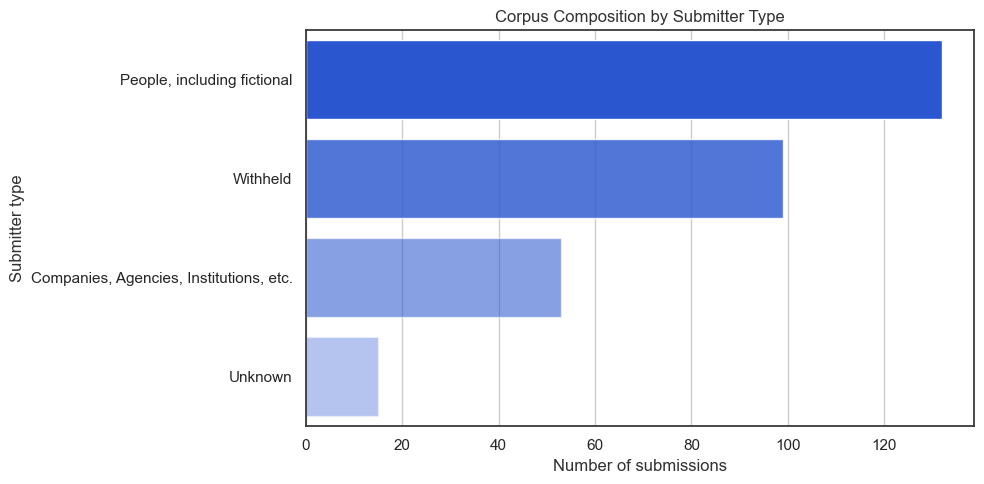

In [48]:
# 3.2 Visual: corpus composition by submitter type

submitter_counts = (
    corpus_df["submitter_type"]
    .value_counts()
    .rename_axis("submitter_type")
    .reset_index(name="count")
)

visuals.bar(
    data=submitter_counts,
    x="count",
    y="submitter_type",
    title="Corpus Composition by Submitter Type",
    xlabel="Number of submissions",
    ylabel="Submitter type",
    color=UTS_PALETTE["blue"],
    gradient_by_value=True,
    alpha_min=0.35,
    alpha_max=1.0,
    figsize=(10, 5),
)

The corpus is clearly not evenly distributed across submitter types, which means this is not a balanced dataset in the statistical sense. Individual submissions and withheld name submissions make up a large share of the corpus, while organisation-style submissions are fewer in number.


<a id="33-distribution-of-document-word-counts"></a>

### 3.3 Distribution of document word counts

This histogram shows the spread of document sizes across submissions.

A **histogram** groups numeric values into bins and shows how often values fall into each range. Here, it helps answer a simple but important question: are most submissions roughly similar in length, or is the corpus dominated by a small number of very short or very long documents?

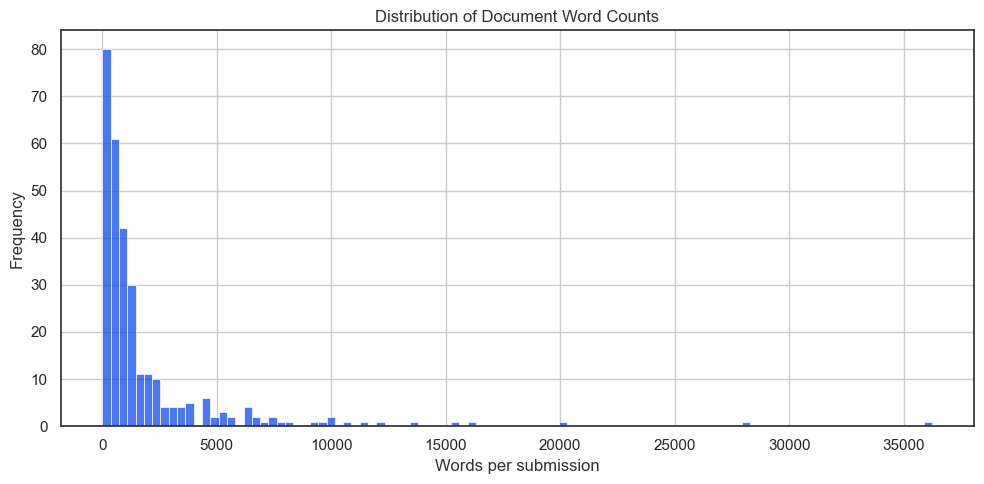

In [49]:
# 3.3 Visual: word count distribution

visuals.hist(
    series=corpus_df["word_count_raw"],
    bins=100,
    color=UTS_PALETTE["blue"],
    edgecolor=UTS_PALETTE["white"],
    title="Distribution of Document Word Counts",
    xlabel="Words per submission",
    ylabel="Frequency",
    figsize=(10, 5),
)

Most submissions cluster in the shorter to middle length range, while a relatively small number extend far to the right of the chart as very large documents. That pattern is called **right skew**: the majority of values are lower, but a minority of very large cases stretch the distribution upward.

**Why this matters.** In a skewed corpus like this one, the **median** is often more informative than the mean because the mean can be pulled upward by unusually long submissions. This chart therefore suggests that the "typical" submission is much shorter than the few largest reports, which is useful context for later comparisons of vocabulary and topic prevalence.

In [50]:
# Find and show the entire row for the document with the largest word count
max_word_count_row = corpus_df.loc[corpus_df["word_count_raw"].idxmax()]
print("Document with the largest word count (entire row):")
display(max_word_count_row.to_frame().T)

# Find and show the entire row for the document with the smallest word count
min_word_count_row = corpus_df.loc[corpus_df["word_count_raw"].idxmin()]
print("Document with the smallest word count (entire row):")
display(min_word_count_row.to_frame().T)

Document with the largest word count (entire row):


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
140,Sub141 Att1 - Malcolm Mackerras.pdf,Sub141 Att1,Malcolm Mackerras,"People, including fictional",96,True,Inquiry into the 2025 federal election\nSubmis...,216098,36258


Document with the smallest word count (entire row):


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
14,Sub015 - Name withheld.pdf,Sub015,Name withheld,Withheld,1,True,Inquiry into the 2025 federal election\nSubmis...,52,8


Looking directly at the largest and smallest submissions makes the skewness in the histogram concrete. The longest document shows how much detail a single submission can contribute, while the shortest document shows that some cases may function more like brief statements than full reports.

**Why this matters.** Outlier inspection is a useful EDA habit because it turns abstract distribution summaries into real documents. It also warns us that a few especially long submissions could influence later corpus wide counts more than their document count alone would suggest.


<a id="34-relationship-between-pages-and-word-counts"></a>

### 3.4 Relationship between pages and word counts

This scatter plot compares page counts with total words to show document scale relationships.

A **scatter plot** is useful when we want to see whether two numeric variables move together. Here, the question is whether the physical size of a submission in pages aligns with the amount of extracted text in words.

/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_24190/1716582564.py:87: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax)


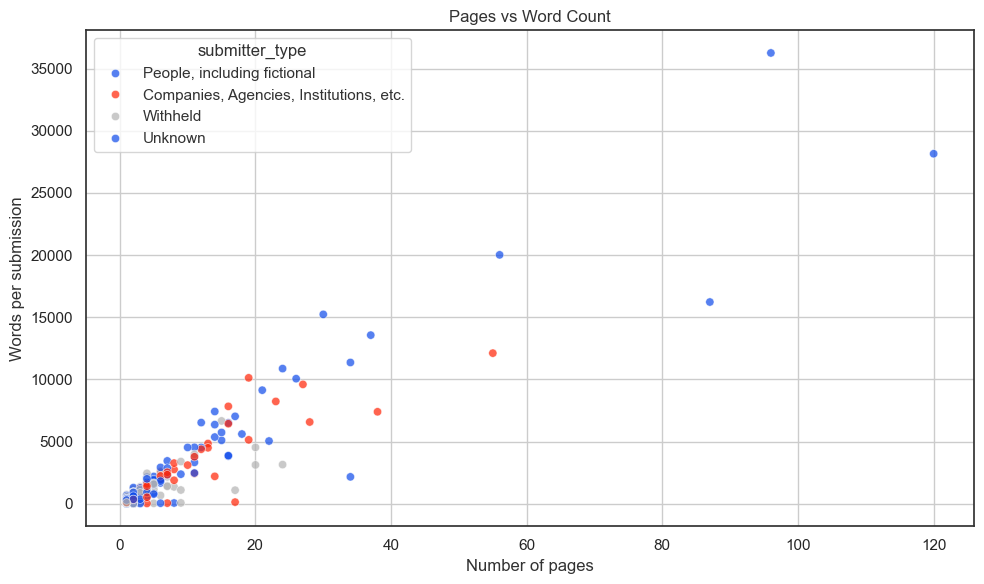

In [51]:
# 3.4 Visual: pages vs word counts

visuals.scatter(
    data=corpus_df,
    x="n_pages",
    y="word_count_raw",
    hue="submitter_type",
    palette=[UTS_PALETTE["blue"], UTS_PALETTE["red"], UTS_PALETTE["mid_grey"]],
    alpha=0.7,
    title="Pages vs Word Count",
    xlabel="Number of pages",
    ylabel="Words per submission",
    figsize=(10, 6),
)

The scatter plot reveals a positive but imperfect correlation between page count and word count, confirming that the PDF extraction pipeline has captured text at a scale consistent with the physical size of each document. The relationship is roughly linear for shorter submissions (up to about 20 pages), where each additional page contributes a fairly predictable number of words, but beyond that range the spread increases noticeably, meaning the words per page ratio becomes much less stable in longer documents. Several high page count outliers (above 80 pages) appear in the upper right corner, corresponding to unusually detailed individual submissions that could dominate corpus level statistics if left unweighted, while a handful of moderate page count submissions (around 20 to 35 pages) sit near the y axis baseline, suggesting those PDFs contain substantial non textual content such as images, tables, or scanned pages with limited extractable text. Color coding by `submitter_type` shows that **People (including fictional)** submissions span the widest range on both axes, from single page letters to the longest documents in the dataset, indicating highly variable engagement levels, whereas **Companies, Agencies, and Institutions** tend to cluster in the low to mid range, pointing to more standardized or templated formats.


<a id="35-character-counts-by-submitter-type"></a>

### 3.5 Character counts by submitter type

This boxplot compares character count distributions by submitter category.

A **boxplot** summarizes the center, spread, and outliers of a distribution. It is especially useful when document lengths vary widely, because it shows the median and the typical range more clearly than a simple bar chart.

/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_24190/1716582564.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)
/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_24190/1716582564.py:68: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)


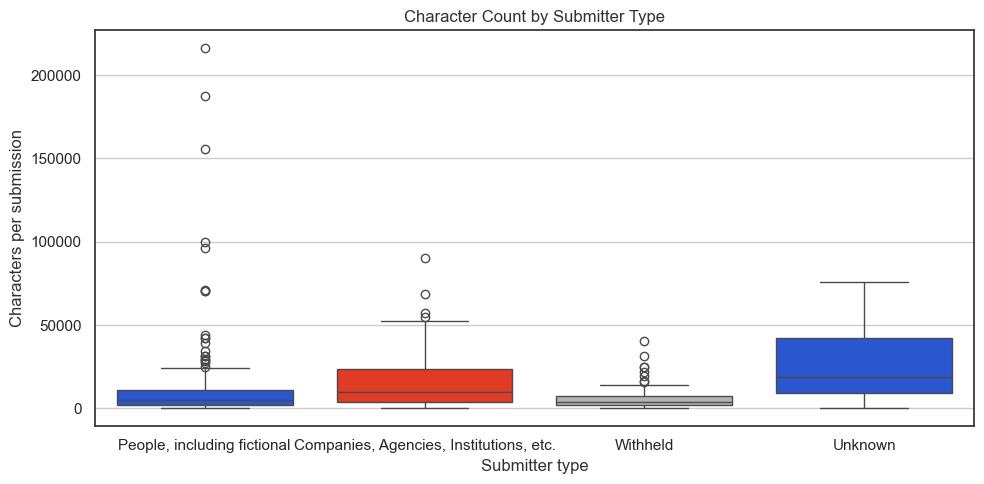

In [52]:
# 3.5 Visual: character count by submitter type

visuals.box(
    data=corpus_df,
    x="submitter_type",
    y="char_count",
    palette=[UTS_PALETTE["blue"], UTS_PALETTE["red"], UTS_PALETTE["mid_grey"]],
    title="Character Count by Submitter Type",
    xlabel="Submitter type",
    ylabel="Characters per submission",
    figsize=(10, 5),
)

Character counts vary substantially both within and across submitter types. Individual submissions (People) have a low median but the widest spread, with extreme outliers exceeding 200,000 characters, while organizational submissions (Companies, Agencies, Institutions) cluster around a higher median with a broader interquartile range, reflecting more consistently substantial, report style documents. Withheld submissions form the most compact distribution with the lowest median, and the Unknown category, despite few data points, shows a surprisingly high median and wide range. The numerous outliers above the upper whiskers across all groups confirm the heavy right skew seen in earlier charts, meaning a small number of very long documents carry a disproportionate share of the total text. This supports the later use of median based summaries, per document normalization, and cleaned token counts rather than relying solely on corpus wide totals.


<a id="36-linguistic-annotation-sample-ner-and-pos"></a>

### 3.6 Linguistic annotation sample (NER and POS)

This section uses two common NLP annotation tasks to make the language in the corpus more interpretable before preprocessing and modeling.

**Named Entity Recognition (NER)** identifies spans of text corresponding to real world entities such as people, organisations, places, dates, laws, or quantities. In a corpus like this one, NER is helpful because it shows which institutions, actors, and locations are explicitly named in the submissions.

**Part of Speech (POS) tagging** assigns a grammatical role to each token, such as noun, verb, adjective, or determiner. It does not tell us the topic directly, but it helps us understand what kind of language dominates the corpus and whether the text is likely to support later thematic analysis.

#### Named Entity Recognition (NER) sample view

The rendered sample below is included as a qualitative view rather than a full quantitative analysis. Its purpose is to make entity detection visible to the reader so the report does not treat NER as a hidden black box.

In [53]:
# 3.7 NER sample rendering

if NLP is None:
    print("spaCy model unavailable, so inline NER rendering is skipped in this environment.")
else:
    ner_sample_sentences = []

    for text in corpus_df["raw_text"].fillna("").head(40):
        doc = NLP(str(text)[:6000])
        for sent in doc.sents:
            sent_text = re.sub(r"\s+", " ", sent.text).strip()
            if 50 <= len(sent_text) <= 220 and sent.ents:
                ner_sample_sentences.append(sent_text)
            if len(ner_sample_sentences) >= 10:
                break
        if len(ner_sample_sentences) >= 10:
            break

    if not ner_sample_sentences:
        print("No suitable sentences with named entities were found in the sampled documents.")
    else:
        ner_sample_docs = [NLP(sentence) for sentence in ner_sample_sentences]
        ner_sample_entities_df = MetadataParser.extract_named_entities(
            pd.Series(ner_sample_sentences),
            nlp_model=NLP,
            max_docs=len(ner_sample_sentences),
        )

        print("Sample sentences with detected named entities:")
        spacy.displacy.render(ner_sample_docs, style="ent", jupyter=True)

        print("Entity labels detected in the rendered sample:")
        display(
            ner_sample_entities_df["label"]
            .value_counts()
            .rename_axis("entity_label")
            .reset_index(name="count")
        )

Sample sentences with detected named entities:


Entity labels detected in the rendered sample:


,entity_label,count
0,DATE,8
1,PERCENT,8
2,ORG,6
3,GPE,5
4,ORDINAL,1
5,CARDINAL,1


The rendered sample confirms that spaCy reliably detects the entity types central to electoral policy text: **ORG** for institutions like the Senate, **GPE** for jurisdictions such as Tasmania and South Australia, **DATE** for legislative time references, and **PERCENT** / **CARDINAL** for the quantitative evidence submitters use to support their arguments. The high density of annotations in just a few sentences shows that the corpus is rich in formal, fact laden language where named entities carry much of the argumentative weight. NER is not perfect, as some labels may be wrong or entities missed, but this qualitative view makes the detection step transparent so that later results built on entity features can be interpreted with appropriate confidence.

#### Part of Speech (POS) analysis

The chart below tags words in a runtime capped sample of submission text and summarizes the most frequent grammatical categories.

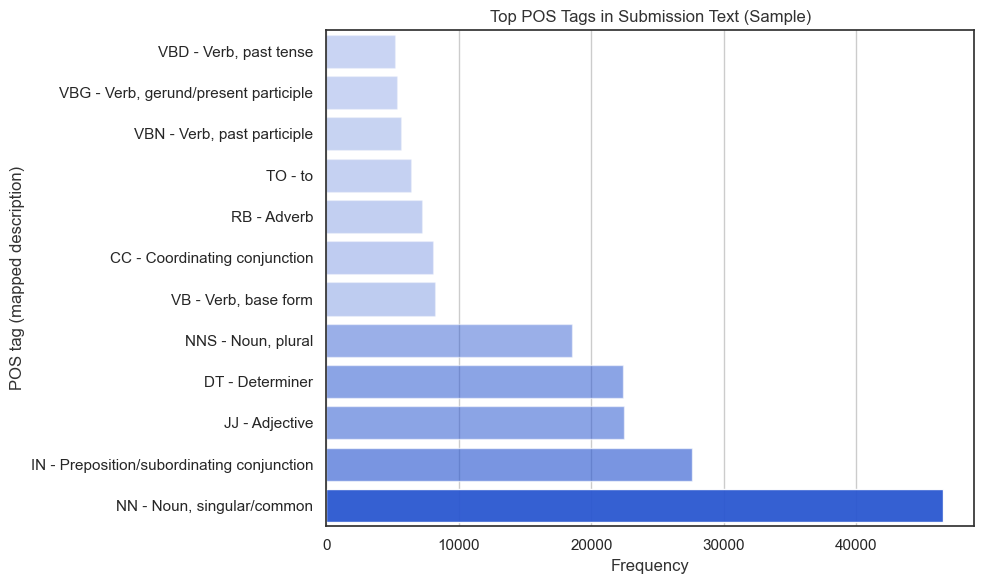

,pos_tag,pos_description,count
11,VBD,"Verb, past tense",5193
10,VBG,"Verb, gerund/present participle",5305
9,VBN,"Verb, past participle",5626
8,TO,to,6401
7,RB,Adverb,7208
6,CC,Coordinating conjunction,8055
5,VB,"Verb, base form",8228
4,NNS,"Noun, plural",18568
3,DT,Determiner,22413
2,JJ,Adjective,22473


In [54]:
# 3.6 POS analysis: top grammatical tags

pos_max_docs = 120
pos_tags = []

for text in corpus_df["raw_text"].head(pos_max_docs):
    tokens = [token.lower() for token in word_tokenize(str(text)) if token.isalpha()]
    if not tokens:
        continue
    pos_tags.extend(tag for _, tag in pos_tag(tokens))

pos_tag_counts = pd.Series(pos_tags, name="pos_tag").value_counts().reset_index()
pos_tag_counts.columns = ["pos_tag", "count"]
pos_tag_counts["pos_description"] = pos_tag_counts["pos_tag"].map(PENN_POS_TAG_MAP).fillna("Other/Unknown")
pos_tag_counts["pos_label"] = pos_tag_counts["pos_tag"] + " - " + pos_tag_counts["pos_description"]

top_pos_tags = pos_tag_counts.head(12).sort_values("count", ascending=True)

LOGGER.debug(
    "POS tagging complete: docs=%d, tagged_tokens=%d",
    min(pos_max_docs, len(corpus_df)),
    len(pos_tags),
)

visuals.bar(
    data=top_pos_tags,
    x="count",
    y="pos_label",
    color=UTS_PALETTE["blue"],
    title="Top POS Tags in Submission Text (Sample)",
    xlabel="Frequency",
    ylabel="POS tag (mapped description)",
    figsize=(10, 6),
)

top_pos_tags[["pos_tag", "pos_description", "count"]]

Nouns, prepositions, determiners, and adjectives dominate the POS profile. That is typical of formal policy style submissions because these documents spend a lot of time naming institutions, actors, procedures, and issues rather than using conversational or narrative language.


<a id="4-preprocessing"></a>

## 4. Preprocessing


<a id="41-prepare-cleaned-tokens-and-lexical-metrics"></a>

### 4.1 Prepare cleaned tokens and lexical metrics

This cell converts the raw text into analysis ready form through a sequence of steps, each designed to progressively reduce the dimensionality of the data so that later models work with a smaller, more meaningful vocabulary instead of a noisy, inflated one.

**Step 1 — URL cleanup and clean tokens.** Before tokenization, URLs are removed from `raw_text` using a regex pattern (matching both `http(s)://` and `www.` links) so web addresses do not pollute lexical features. The `clean_tokens` method then applies POS filtering to keep only nouns, proper nouns, adjectives, and verbs, which are the parts of speech that carry the most topical meaning. Stopwords, punctuation, and non alphabetic tokens are discarded. The result is a focused token list that removes high frequency, low information words and dramatically reduces the number of unique features the corpus contains.

**Step 2 — Bigram phrase detection.** Gensim's `Phrases` model is used with `scoring="npmi"` to detect collocations in the cleaned token stream. Bigrams that satisfy `min_count=3` and `threshold=0.5` are merged into underscore phrases (for example, `electoral` + `commission` -> `electoral_commission`) so the representation keeps multi-word concepts as single units while filtering weaker pairs.

**Step 3 — Trigram extraction.** Trigrams are generated directly from cleaned tokens using `nltk.trigrams`, producing contiguous three-word windows that are stored as underscore-joined phrase tokens.

**Step 4 — Lemmatization.** Each token is mapped to its base dictionary form using NLTK's `WordNetLemmatizer`. Penn Treebank POS tags are converted to WordNet tags so the lemmatizer can apply the correct morphological rules (for example, `votes`, `voted`, and `voting` all become `vote`, while adjectives and adverbs are handled by their own rules). By merging inflected variants into a common lemma, this step compresses the vocabulary even further, ensuring that surface level variation does not artificially inflate feature counts in downstream models like TF-IDF, topic modeling, and clustering.

Finally, the cell computes per document metrics including **cleaned word count** and **lexical diversity** (the ratio of unique tokens to total tokens) so these values are available for all subsequent comparisons.

In [55]:
# 4.1 Tokenization output and document level lexical features

# Remove URLs before tokenization so links do not pollute lexical features.
corpus_df["text_no_urls"] = (
    corpus_df["raw_text"]
    .fillna("")
    .astype(str)
    .str.replace(r"(?:https?://|www\.)\S+", " ", regex=True)
)

corpus_df["raw_tokens"] = corpus_df["text_no_urls"].apply(
    lambda text: [token.lower() for token in word_tokenize(str(text)) if token.isalpha()]
)
corpus_df["clean_tokens"] = corpus_df["text_no_urls"].apply(preprocessor.clean_tokens)

# Remove records where the clean_tokens list is empty
corpus_df = corpus_df[corpus_df["clean_tokens"].str.len() > 0].copy().reset_index(drop=True)

# Build NPMI bigrams with Gensim Phrases and trigrams with nltk.trigrams.
bigram_model = preprocessor.fit_bigram_model(corpus_df["clean_tokens"], min_count=3, threshold=0.5)

# Keep existing column names for downstream compatibility.
corpus_df["pmi_bigram_tokens"] = corpus_df["clean_tokens"].apply(
    lambda tokens: preprocessor.apply_phrase_model(tokens, bigram_model)
)
corpus_df["pmi_trigram_tokens"] = corpus_df["clean_tokens"].apply(preprocessor.generate_trigram_tokens)

# Join bigram and trigram outputs, but avoid duplicated unigrams.
corpus_df["combined_phrase_tokens"] = corpus_df.apply(
    lambda row: preprocessor.combine_phrase_tokens(row["pmi_bigram_tokens"], row["pmi_trigram_tokens"]),
    axis=1,
)

corpus_df["lemmatized_tokens"] = corpus_df["combined_phrase_tokens"].apply(preprocessor.lemmatize_tokens)
corpus_df["preprocessed_text"] = corpus_df["lemmatized_tokens"].apply(" ".join)

corpus_df["clean_word_count"] = corpus_df["clean_tokens"].str.len()
corpus_df["lexical_diversity"] = corpus_df.apply(
    lambda r: (len(set(r["clean_tokens"])) / r["clean_word_count"]) if r["clean_word_count"] > 0 else np.nan,
    axis=1,
)

raw_all_tokens = [token for tokens in corpus_df["raw_tokens"] for token in tokens]
all_tokens = [token for tokens in corpus_df["clean_tokens"] for token in tokens]
pmi_bigram_vocab = {token for tokens in corpus_df["pmi_bigram_tokens"] for token in tokens}
pmi_trigram_vocab = {token for tokens in corpus_df["pmi_trigram_tokens"] for token in tokens}
combined_phrase_vocab = {token for tokens in corpus_df["combined_phrase_tokens"] for token in tokens}
lemmatized_vocab = {token for tokens in corpus_df["lemmatized_tokens"] for token in tokens}
vocab_size = len(set(all_tokens))
LOGGER.debug(
    "Tokenization complete: raw_vocab_size=%d, clean_vocab_size=%d, bigram_vocab_size=%d, trigram_vocab_size=%d, combined_vocab_size=%d, lemmatized_vocab_size=%d, docs=%d",
    len(set(raw_all_tokens)),
    vocab_size,
    len(pmi_bigram_vocab),
    len(pmi_trigram_vocab),
    len(combined_phrase_vocab),
    len(lemmatized_vocab),
    len(corpus_df),
)

corpus_df[["file_name", "clean_tokens", "pmi_bigram_tokens", "pmi_trigram_tokens", "combined_phrase_tokens", "lemmatized_tokens"]].head(10)


2026-03-14 08:06:38,320 | INFO | collecting all words and their counts
2026-03-14 08:06:38,322 | INFO | PROGRESS: at sentence #0, processed 0 words and 0 word types
2026-03-14 08:06:38,493 | INFO | collected 185851 token types (unigram + bigrams) from a corpus of 256740 words and 276 sentences
2026-03-14 08:06:38,493 | INFO | merged Phrases<185851 vocab, min_count=3, threshold=0.5, max_vocab_size=40000000>
2026-03-14 08:06:38,494 | INFO | Phrases lifecycle event {'msg': 'built Phrases<185851 vocab, min_count=3, threshold=0.5, max_vocab_size=40000000> in 0.17s', 'datetime': '2026-03-14T08:06:38.494415', 'gensim': '4.4.0', 'python': '3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]', 'platform': 'macOS-26.1-arm64-arm-64bit', 'event': 'created'}
2026-03-14 08:06:38,494 | INFO | exporting phrases from Phrases<185851 vocab, min_count=3, threshold=0.5, max_vocab_size=40000000>
2026-03-14 08:06:38,630 | INFO | FrozenPhrases lifecycle event {'msg': 'expor

,file_name,clean_tokens,pmi_bigram_tokens,pmi_trigram_tokens,combined_phrase_tokens,lemmatized_tokens
0,Sub001 - Bob McMullan.pdf,"[time, revisit, territory, representation, int...","[time, revisit, territory, representation, int...","[time_revisit_territory, revisit_territory_rep...","[time, revisit, territory, representation, int...","[time, revisit, territory, representation, int..."
1,Sub002 - Dr Sheppard.pdf,"[national, university, possible, solutions, mo...","[national, university, possible, solutions, mo...","[national_university_possible, university_poss...","[national, university, possible, solutions, mo...","[national, university, possible, solution, mon..."
2,Sub003 - Grattan Institute.pdf,"[grattan, institute, september, aruna, kate, g...","[grattan_institute, september, aruna, kate, gr...","[grattan_institute_september, institute_septem...","[grattan_institute, september, aruna, kate, gr...","[grattan_institute, september, aruna, kate, gr..."
3,Sub004 - Australian Electoral Commission.pdf,"[aec, joint, standing, matters, aec, joint, st...","[aec, joint_standing, matters, aec, joint_stan...","[aec_joint_standing, joint_standing_matters, s...","[aec, joint_standing, matters, joint_standing,...","[aec, joint_standing, matter, joint_standing, ..."
4,Sub005 - The Australia Institute.pdf,"[democracy, thriving, inventive, democracy, me...","[democracy, thriving, inventive, democracy, me...","[democracy_thriving_inventive, thriving_invent...","[democracy, thriving, inventive, measured, ref...","[democracy, thrive, inventive, measure, reform..."
5,Sub006 - Andrew Murray.pdf,"[secretary, joint, standing, matters, box, hou...","[secretary_joint, standing_matters, box, house...","[secretary_joint_standing, joint_standing_matt...","[secretary_joint, standing_matters, box, house...","[secretary_joint, standing_matters, box, house..."
6,Sub007 - Genevieve Grant.pdf,"[page, written, joint, standing, matters, refe...","[page, written, joint_standing, matters, refer...","[page_written_joint, written_joint_standing, j...","[page, written, joint_standing, matters, refer...","[page, write, joint_standing, matter, referenc..."
7,Sub008 - Richard Ure.pdf,"[years, epping, first, suburb, sydney, declare...","[years, epping, first, suburb, sydney, declare...","[years_epping_first, epping_first_suburb, firs...","[years, epping, first, suburb, sydney, declare...","[year, epping, first, suburb, sydney, declare,..."
8,Sub009 - Barry Searle.pdf,"[barry, searle, sept, time, banned, poll, boot...","[barry, searle, sept, time, banned, poll, boot...","[barry_searle_sept, searle_sept_time, sept_tim...","[barry, searle, sept, time, banned, poll, boot...","[barry, searle, sept, time, ban, poll, booth, ..."
9,Sub010 - Name withheld.pdf,"[regarding, brief, voted, day, polling, ended,...","[regarding, brief, voted, day, polling, ended,...","[regarding_brief_voted, brief_voted_day, voted...","[regarding, brief, voted, day, polling, ended,...","[regard, brief, vote, day, polling, end, wait,..."


This preprocessing step creates several parallel versions of the text, from raw tokens to cleaned tokens, phrase-aware tokens, and finally lemmatized tokens. That layered approach is useful because different tasks need different text representations: simple counts can use `clean_tokens`, phrase analysis needs the bigram output, and modeling benefits from the more normalized `preprocessed_text` field.

**Why this matters.** Good preprocessing is not just about deleting words. It is about creating a representation of the corpus that keeps meaning while reducing noise, so later results are easier to interpret and less distorted by formatting or grammar variation.

In [56]:
# Find the top 10 longest tokens in the clean_tokens column across all documents,
# and identify the document(s) each token belongs to

from collections import defaultdict

# Flatten all tokens from clean_tokens and get unique tokens
all_clean_tokens = [token for tokens in corpus_df["clean_tokens"] for token in tokens]
unique_clean_tokens = set(all_clean_tokens)

# Get the top 10 longest tokens (by length, then alphabetically for ties)
longest_tokens = sorted(unique_clean_tokens, key=lambda t: (-len(t), t))[:10]

print("Top 10 longest tokens in clean_tokens (by length):")
for rank, token in enumerate(longest_tokens, 1):
    docs_with_token = corpus_df[corpus_df["clean_tokens"].apply(lambda tokens: token in tokens)]
    file_names = docs_with_token["file_name"].tolist()
    print(f"{rank}. '{token}' (Length: {len(token)}), Documents:")
    for fname in file_names:
        print("   -", fname)

Top 10 longest tokens in clean_tokens (by length):
1. 'accbdefafdebbcecca' (Length: 18), Documents:
   - Sub121 - Thomas Stephen.pdf
2. 'contentcreatorspdf' (Length: 18), Documents:
   - SupSub004.2 - Australian Electoral Commission.pdf
3. 'counterinformation' (Length: 18), Documents:
   - Sub096 - Name withheld.pdf
4. 'determinationshtml' (Length: 18), Documents:
   - Sub051 Att 1 - Travis Jordan.pdf
5. 'disabtedvotunteers' (Length: 18), Documents:
   - Sub276 - Name withheld.pdf
6. 'disenfranchisement' (Length: 18), Documents:
   - Sub004 - Australian Electoral Commission.pdf
   - Sub005 - The Australia Institute.pdf
   - Sub051 - Travis Jordan.pdf
   - Sub135 - Human Rights Law Centre.pdf
   - Sub191 - Name withheld.pdf
   - Sub250 - Cillin Perera.pdf
   - Sub268 - Tony Fairweather.pdf
   - SupSub004.2 - Australian Electoral Commission.pdf
   - SupSub083.1 -  Global Shield Australia.pdf
7. 'disproportionality' (Length: 18), Documents:
   - Sub059 - Ben Raue.pdf
   - Sub261 - Proport


<a id="42-most-common-words"></a>

### 4.2 Most common words

This subsection focuses on visualization only. Using the cleaned tokens prepared in the previous step, it shows the most common terms across the full corpus and within each `submitter_type`.

The concept here is **term frequency**: counting how often words appear. Frequency is simple, but it is often the clearest first signal of what the corpus is about once obvious stopwords and formatting noise have been removed.

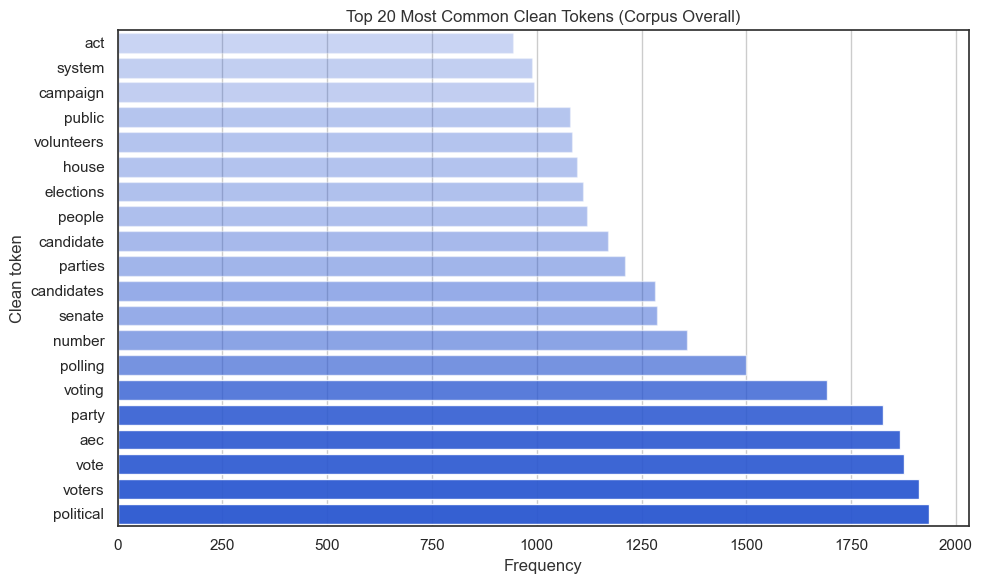

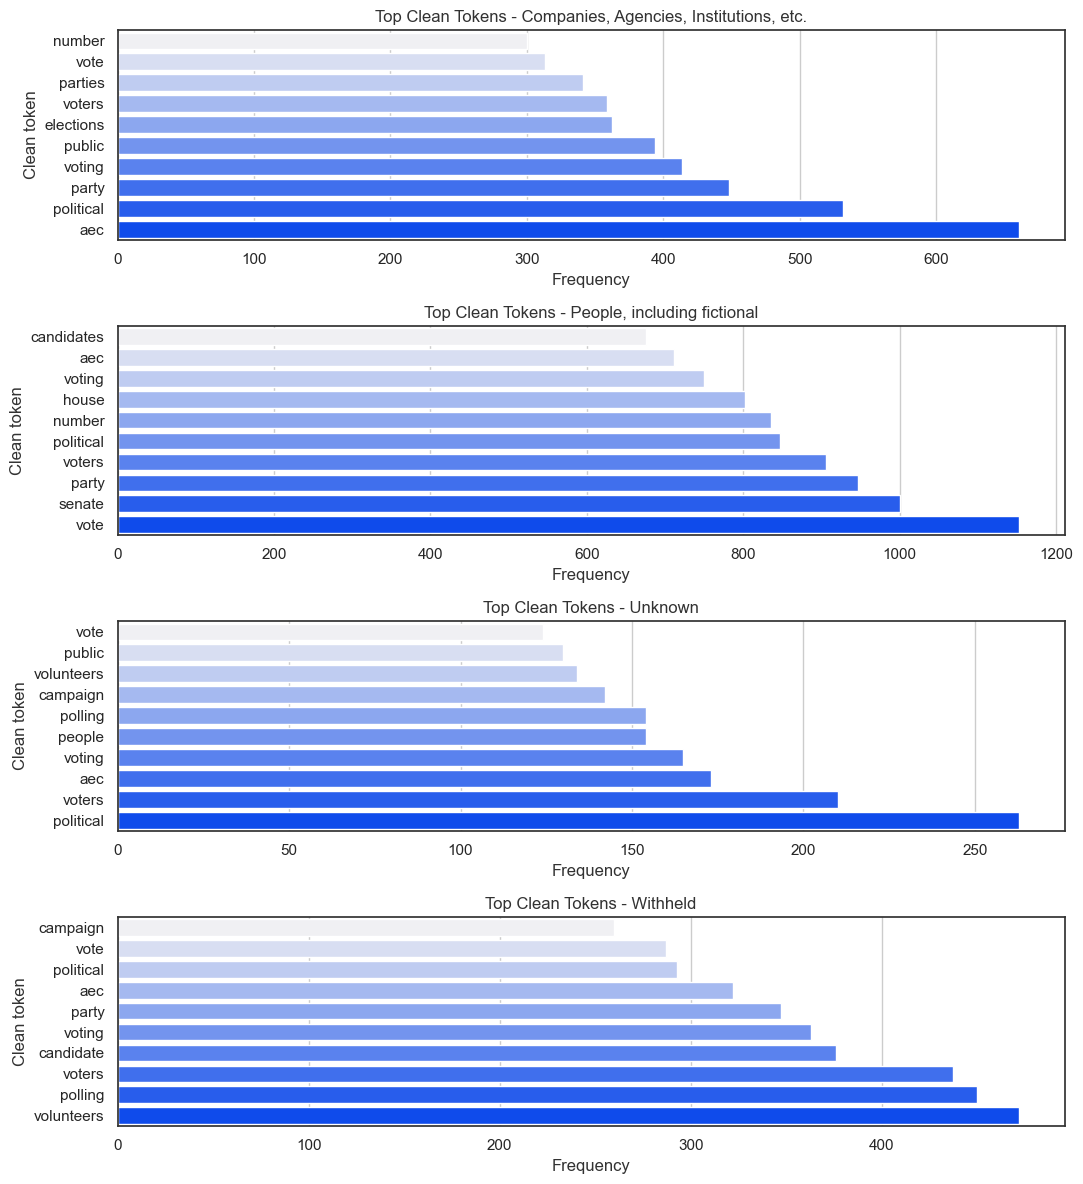

Top clean tokens by submitter type (top 10 each):


,submitter_type,word,count
0,"Companies, Agencies, Institutions, etc.",aec,661
1,"Companies, Agencies, Institutions, etc.",political,532
2,"Companies, Agencies, Institutions, etc.",party,448
3,"Companies, Agencies, Institutions, etc.",voting,414
4,"Companies, Agencies, Institutions, etc.",public,394
5,"Companies, Agencies, Institutions, etc.",elections,362
6,"Companies, Agencies, Institutions, etc.",voters,359
7,"Companies, Agencies, Institutions, etc.",parties,341
8,"Companies, Agencies, Institutions, etc.",vote,313
9,"Companies, Agencies, Institutions, etc.",number,300


In [57]:
# 4.2 Visuals: most common words (clean tokens)

overall_word_counter = Counter(all_tokens)
top_words_df = pd.DataFrame(overall_word_counter.most_common(20), columns=["word", "count"])
plot_top_words = top_words_df.sort_values("count", ascending=True)

LOGGER.debug("Clean token visualization prepared: unique_clean_tokens=%d", len(overall_word_counter))

# Chart 1: overall top clean tokens
visuals.bar(
    data=plot_top_words,
    x="count",
    y="word",
    color=UTS_PALETTE["blue"],
    title="Top 20 Most Common Clean Tokens (Corpus Overall)",
    xlabel="Frequency",
    ylabel="Clean token",
    figsize=(10, 6),
)

# Top clean tokens by submitter type
rows = []
for submitter_type, group_df in corpus_df.groupby("submitter_type"):
    type_tokens = [
        token
        for tokens in group_df["clean_tokens"]
        for token in tokens
    ]
    type_counter = Counter(type_tokens)
    for word, count in type_counter.most_common(10):
        rows.append({"submitter_type": submitter_type, "word": word, "count": count})

top_words_by_type_df = pd.DataFrame(rows)

# Chart 2: top clean tokens by submitter type (faceted)
submitter_types = list(top_words_by_type_df["submitter_type"].dropna().unique())
fig, axes = plt.subplots(
    nrows=len(submitter_types),
    ncols=1,
    figsize=(11, max(3 * len(submitter_types), 6)),
    sharex=False,
)

if len(submitter_types) == 1:
    axes = [axes]

for ax, submitter_type in zip(axes, submitter_types):
    type_data = (
        top_words_by_type_df[top_words_by_type_df["submitter_type"] == submitter_type]
        .sort_values("count", ascending=True)
    )

    sns.barplot(data=type_data, x="count", y="word", color=UTS_PALETTE["blue"], ax=ax)

    gradient_colors = sns.light_palette(UTS_PALETTE["blue"], n_colors=len(type_data))
    for bar, color in zip(ax.patches, gradient_colors):
        bar.set_facecolor(color)

    ax.set_title(f"Top Clean Tokens - {submitter_type}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Clean token")

plt.tight_layout()
plt.show()

print("Top clean tokens by submitter type (top 10 each):")
top_words_by_type_df.sort_values(["submitter_type", "count"], ascending=[True, False]).head(60)


Because these charts use `clean_tokens`, the dominant terms are easier to interpret than raw token counts and better reflect substantive inquiry themes rather than formatting noise or stopwords. The overall chart highlights the shared vocabulary that anchors the corpus, while the faceted charts show whether those priorities are consistent across submitter groups or whether some groups emphasize different concerns.

**Why this matters.** Word frequency patterns are often the clearest bridge between raw text and later topic models. If a few cleaned terms dominate across most groups, that suggests strong common concerns in the corpus. If the vocabulary diverges by `submitter_type`, that strengthens the case for looking at group differences and latent thematic structure in more detail.


<a id="43-corpus-snapshot-statistics"></a>

### 4.3 Corpus snapshot statistics

This cell reports compact EDA summary statistics used to frame the visual analysis.

Think of this as a checkpoint in the story: after cleaning the corpus, the notebook pauses to summarize how large, varied, and information rich the text now looks before moving into n grams and models.

In [58]:
# 4.3 Snapshot statistics

print("=== EDA Snapshot ===")
print(f"Documents analysed: {len(corpus_df)}")
print(f"Corpus vocabulary size (clean tokens): {vocab_size:,}")
print(f"Median document word count (raw): {corpus_df['word_count_raw'].median():.0f}")
print(f"Median lexical diversity: {corpus_df['lexical_diversity'].median():.3f}")

=== EDA Snapshot ===
Documents analysed: 276
Corpus vocabulary size (clean tokens): 15,652
Median document word count (raw): 902
Median lexical diversity: 0.645


These headline figures summarize the cleaned corpus in one place: how many submissions are being analyzed, how large the cleaned vocabulary is, how long a typical document is, and how varied the wording tends to be. Together they suggest the corpus is both sizable and diverse enough for more than one method of analysis.

**Why this matters.** Snapshot statistics help keep the later charts anchored. They remind the reader that every topic model, cluster map, and phrase chart is being built on a corpus that is not tiny, not uniform, and not dominated by a single repeated template.


<a id="44-length-comparison-by-submitter-type"></a>

### 4.4 Length comparison by submitter type

This visual compares cleaned document lengths across submitter categories to show whether the same groups remain relatively longer after preprocessing.

The main idea is to check whether differences in document size still hold once common filler language has been removed. If they do, then length differences are likely to reflect real differences in submission style rather than just formatting noise.

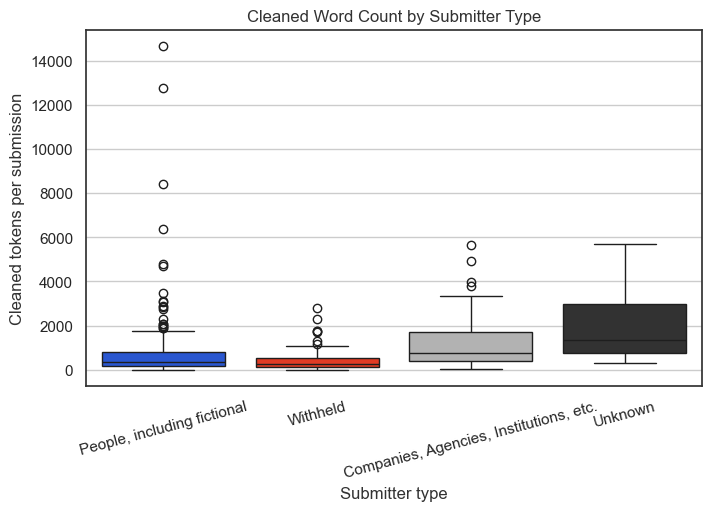

In [59]:
# 4.4 Visual: grouped comparison by submitter type (using clean tokens only)

submitter_order = corpus_df["submitter_type"].dropna().value_counts().index.tolist()
palette_cycle = [
    UTS_PALETTE["blue"],
    UTS_PALETTE["red"],
    UTS_PALETTE["mid_grey"],
    UTS_PALETTE["dark_grey"],
]
submitter_palette = {
    label: palette_cycle[idx % len(palette_cycle)]
    for idx, label in enumerate(submitter_order)
}

# Only plot cleaned word counts, since we want to focus on clean tokens
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

sns.boxplot(
    data=corpus_df,
    x="submitter_type",
    y="clean_word_count",
    order=submitter_order,
    hue="submitter_type",
    palette=submitter_palette,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Cleaned Word Count by Submitter Type")
ax.set_xlabel("Submitter type")
ax.set_ylabel("Cleaned tokens per submission")
ax.tick_params(axis="x", rotation=15)

plt.show()

The grouped comparison shows whether length differences survive the cleaning process. If the same submitter types remain relatively longer after preprocessing, then those differences are likely to reflect genuine variation in how much substantive material each group tends to provide.


<a id="45-frequency-table-preparation-unigrams-npmi-bigrams-and-npmi-trigrams"></a>

### 4.5 Frequency table preparation (unigrams and NPMI bigrams)

This cell computes unigram frequencies from the cleaned token stream and phrase frequencies from the NPMI bigram output so the following charts can compare raw n grams against detected phrase units.

**What these concepts mean:**
A **unigram** is a single token.
A **bigram** is a two word sequence.
**NPMI** (Normalized Pointwise Mutual Information) is a collocation measure that helps identify word combinations that occur together more meaningfully than chance would suggest.

This matters because raw adjacency alone can produce many common but uninformative phrases, whereas NPMI helps highlight combinations that behave more like stable concepts.

In [60]:
# 4.5 Frequency tables

raw_unigram_counts = Counter(raw_all_tokens)
clean_unigram_counts = Counter(all_tokens)
raw_bigram_counts = TextAnalytics.compute_ngram_counts(corpus_df["raw_tokens"], n=2)
raw_trigram_counts = TextAnalytics.compute_ngram_counts(corpus_df["raw_tokens"], n=3)
phrase_bigram_counts = Counter(
    token.replace("_", " ")
    for tokens in corpus_df["pmi_bigram_tokens"]
    for token in tokens
    if token.count("_") == 1
)
phrase_trigram_counts = Counter(
    token.replace("_", " ")
    for tokens in corpus_df["pmi_trigram_tokens"]
    for token in tokens
    if token.count("_") == 2
)

top_raw_unigrams = pd.DataFrame(raw_unigram_counts.most_common(20), columns=["term", "count"])
top_clean_unigrams = pd.DataFrame(clean_unigram_counts.most_common(20), columns=["term", "count"])

top_raw_bigrams = pd.DataFrame(
    [(" ".join(bg), count) for bg, count in raw_bigram_counts.most_common(15)],
    columns=["bigram", "count"],
)
top_phrase_bigrams = pd.DataFrame(
    list(phrase_bigram_counts.most_common(15)),
    columns=["bigram", "count"],
)

top_raw_trigrams = pd.DataFrame(
    [(" ".join(tg), count) for tg, count in raw_trigram_counts.most_common(15)],
    columns=["trigram", "count"],
)
top_phrase_trigrams = pd.DataFrame(
    list(phrase_trigram_counts.most_common(15)),
    columns=["trigram", "count"],
)

print("Top 10 raw unigrams:")
display(top_raw_unigrams.head(10))

print("Top 10 clean unigrams:")
display(top_clean_unigrams.head(10))

print("Top 10 raw bigrams:")
display(top_raw_bigrams.head(10))

print("Top 10 phrase bigrams:")
display(top_phrase_bigrams.head(10))

print("Top 10 raw trigrams:")
display(top_raw_trigrams.head(10))

print("Top 10 phrase trigrams:")
display(top_phrase_trigrams.head(10))

Top 10 raw unigrams:


,term,count
0,the,34990
1,of,17203
2,to,16497
3,and,14984
4,in,10000
5,a,9393
6,that,6236
7,for,6110
8,election,5183
9,is,4989


Top 10 clean unigrams:


,term,count
0,political,1935
1,voters,1912
2,vote,1877
3,aec,1867
4,party,1827
5,voting,1692
6,polling,1500
7,number,1358
8,senate,1286
9,candidates,1283


Top 10 raw bigrams:


...

,bigram,count
0,house representatives,534
1,pre poll,441
2,political parties,356
3,joint standing,290
4,ballot paper,263
5,polling places,237
6,polling booths,230
7,polling booth,230
8,polling place,208
9,social media,204


Top 10 raw trigrams:


,trigram,count
0,the federal election,2418
1,inquiry into the,2175
2,into the federal,2078
3,federal election submission,1957
4,the number of,622
5,house of representatives,527
6,the house of,406
7,joint standing committee,335
8,committee on electoral,334
9,standing committee on,325


Top 10 phrase trigrams:


,trigram,count
0,joint standing matters,321
1,truth political advertising,144
2,new south wales,106
3,ppvc total votes,82
4,state division ppvc,81
5,division ppvc total,81
6,total votes days,81
7,votes days open,81
8,days open avg,81
9,ppvc state division,78



<a id="46-top-unigram-frequency-chart"></a>

### 4.6 Top unigram frequency chart

These charts visualize the most common single word terms in separate raw token and cleaned token views so the effect of preprocessing is easy to compare.

A **unigram frequency chart** is one of the simplest NLP views, but it is very useful for storytelling because it shows how the vocabulary changes once cleaning decisions have been applied.

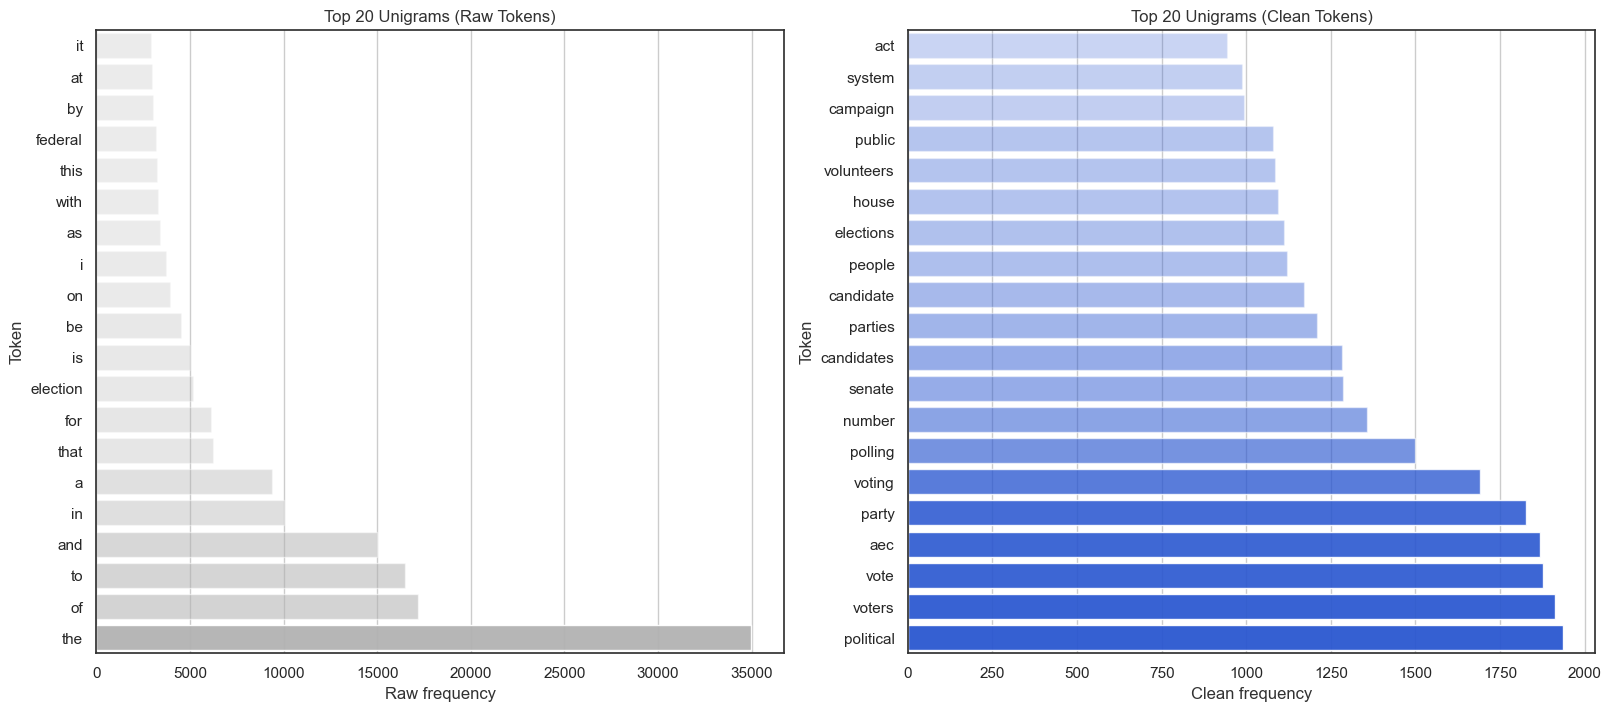

In [61]:
# 4.6 Visual: top unigrams

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_unigrams.sort_values("count", ascending=True),
    x="count",
    y="term",
    color=UTS_PALETTE["mid_grey"],
    title="Top 20 Unigrams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Token",
    ax=axes[0],
)

visuals.bar(
    data=top_clean_unigrams.sort_values("count", ascending=True),
    x="count",
    y="term",
    color=UTS_PALETTE["blue"],
    title="Top 20 Unigrams (Clean Tokens)",
    xlabel="Clean frequency",
    ylabel="Token",
    ax=axes[1],
)

plt.show()

Showing raw and clean unigram charts separately makes the effect of preprocessing much easier to see. The raw token view still contains more generic language, while the cleaned token view concentrates attention on terms that are easier to connect to substantive inquiry themes.

**What the result suggests.** Terms such as `political`, `voters`, `aec`, and `vote` indicate that the corpus remains strongly centered on electoral administration, participation, and institutional process even after general context words are filtered out. That is a useful sign that the cleaning strategy is preserving topic relevant vocabulary rather than stripping too much meaning away.


<a id="47-bigram-phrase-visuals-frequency-chart-and-network-graph"></a>

### 4.7 Bigram phrase visuals (frequency chart and network graph)

This subsection compares frequent raw bigrams with detected NPMI bigram phrases and then visualizes the phrase based bigram structure as a network using the lemmatized phrase tokens.

The two main ideas here are **collocations** and **networks**. A collocation is a word combination that tends to appear together, while a network graph helps show how those phrase elements connect across the corpus rather than only how often they appear.

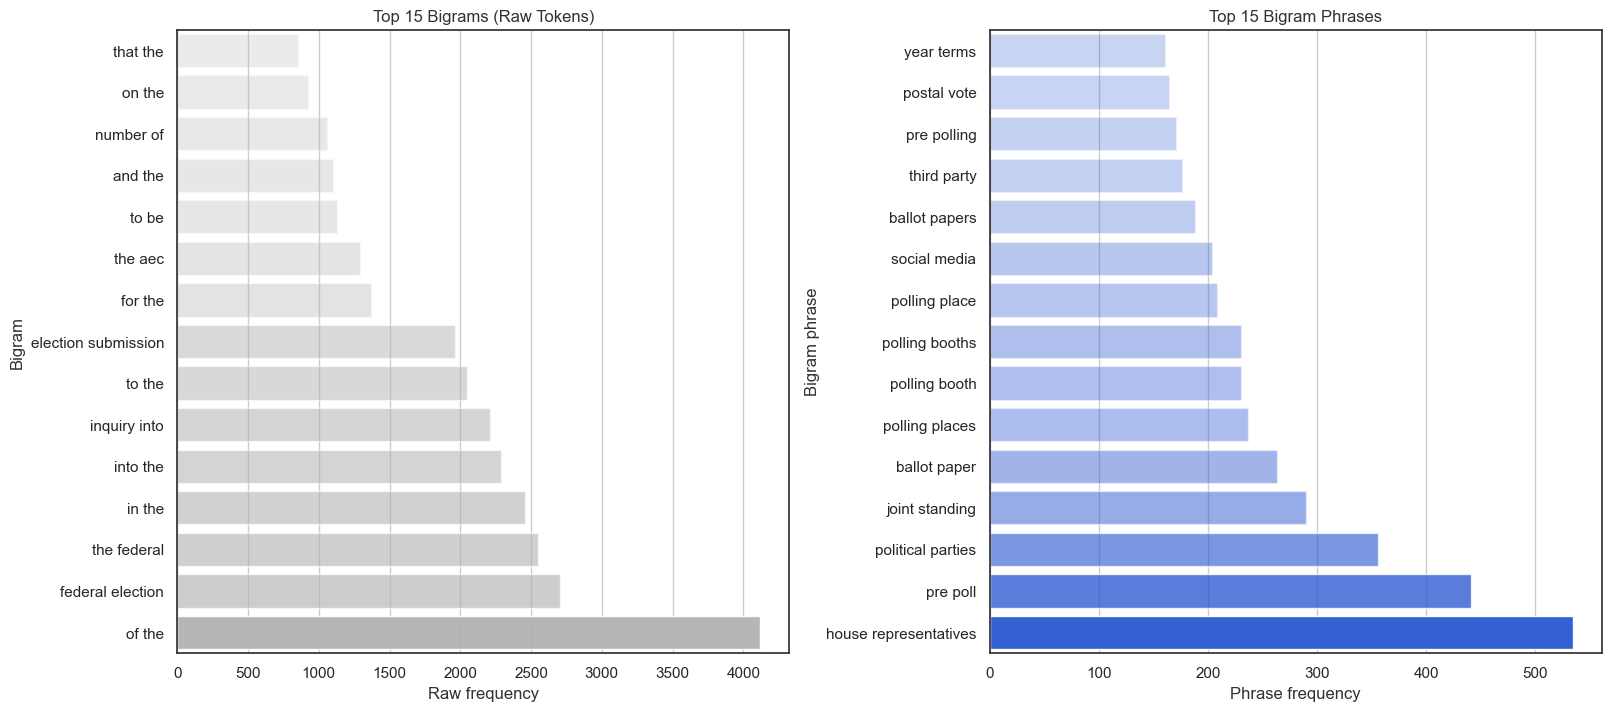

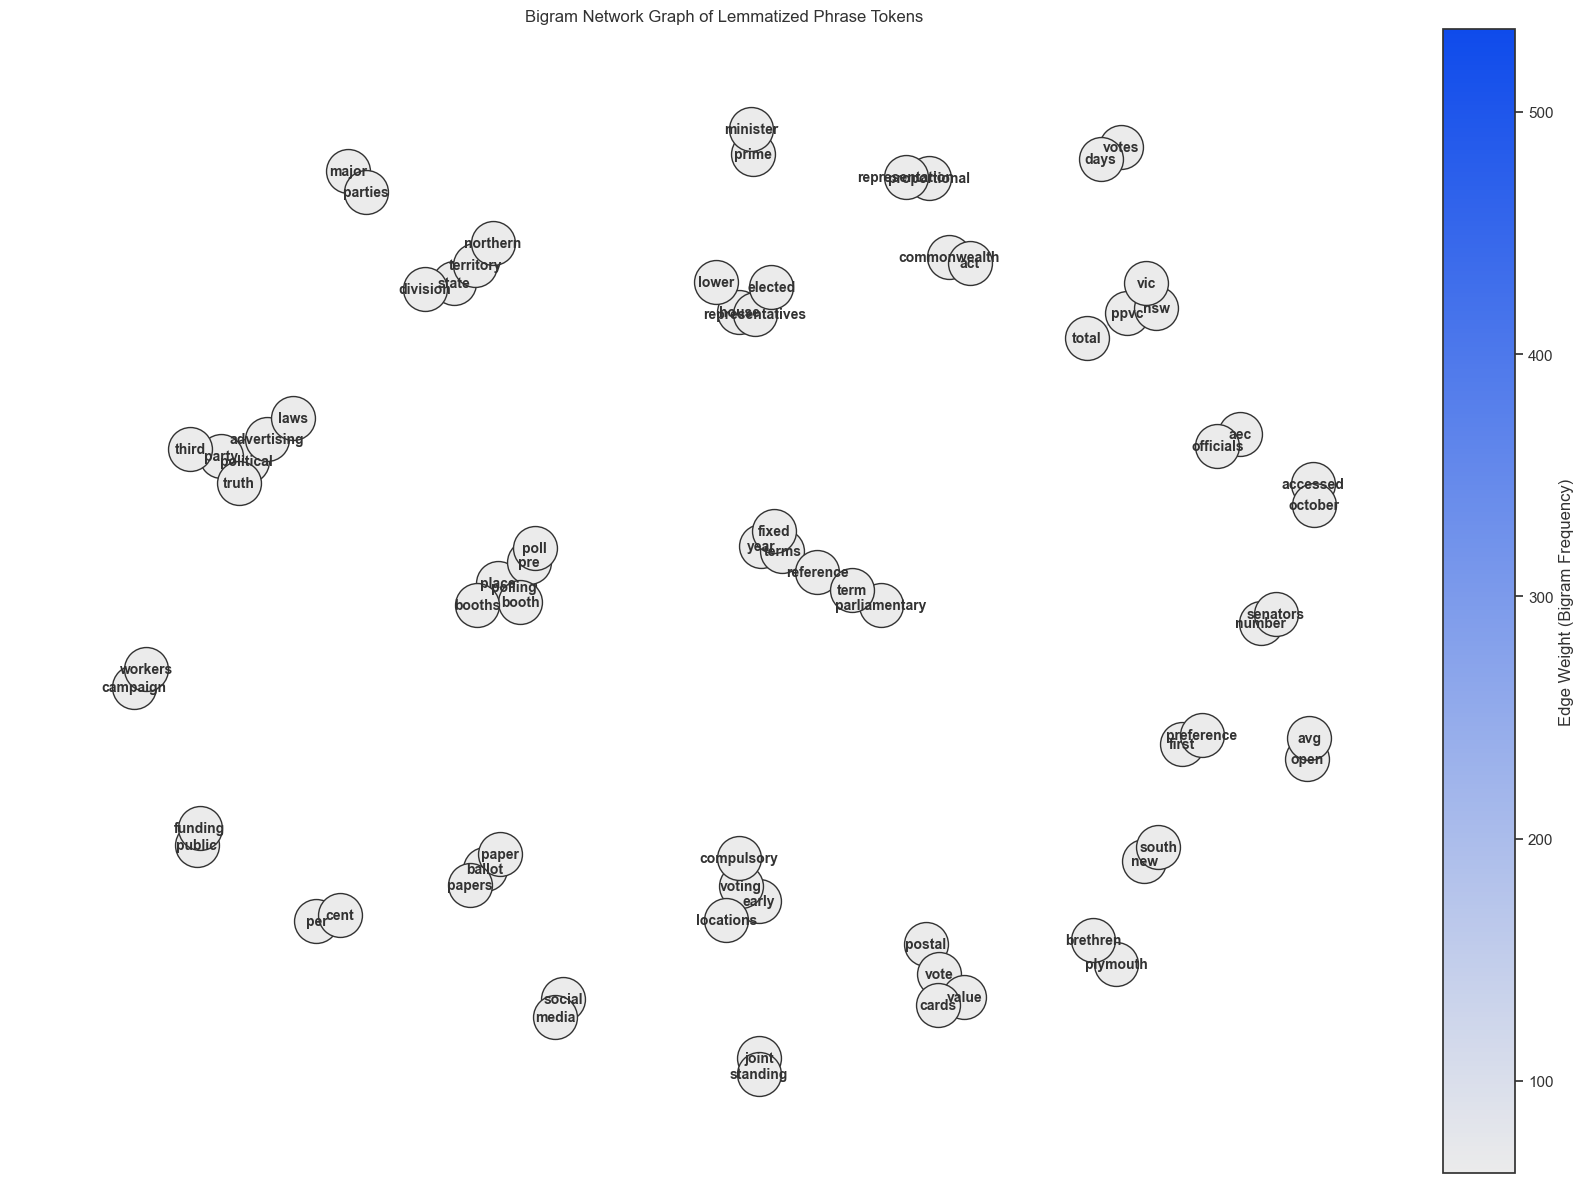

In [62]:
# 4.7 Bigram phrase visuals

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_bigrams.sort_values("count", ascending=True),
    x="count",
    y="bigram",
    color=UTS_PALETTE["mid_grey"],
    title="Top 15 Bigrams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Bigram",
    ax=axes[0],
)

visuals.bar(
    data=top_phrase_bigrams.sort_values("count", ascending=True),
    x="count",
    y="bigram",
    color=UTS_PALETTE["blue"],
    title="Top 15 Bigram Phrases",
    xlabel="Phrase frequency",
    ylabel="Bigram phrase",
    ax=axes[1],
)

plt.show()

lemmatized_phrase_tokens = [
    token
    for tokens in corpus_df["lemmatized_tokens"]
    if isinstance(tokens, list)
    for token in tokens
    if isinstance(token, str) and token.count("_") == 1
]

visuals.bigram_network(
    tokens=lemmatized_phrase_tokens,
    title="Bigram Network Graph of Lemmatized Phrase Tokens",
    n=50,
    figsize=(16, 12),
)

Bigrams add more context than single terms, and the NPMI phrase model highlights word pairs that cohere strongly enough to be treated as phrase like units. Comparing raw bigrams with detected NPMI bigram phrases shows the difference between simple adjacency and more meaningful collocations.

**What the result adds to the story.** When terms begin to form stable pairs, the discussion becomes more interpretable because the corpus is no longer just about isolated words. The network graph then makes those phrase relationships visible as a structure, showing which ideas are repeatedly connected across the submissions rather than simply frequent in isolation.


<a id="48-top-three-gram-frequency-chart-using-npmi-phrase-output"></a>

### 4.8 Top three-gram frequency chart

This section compares raw trigram frequencies with phrase-detected trigrams to show which three-word patterns emerge directly from token sequences versus phrase model detection.

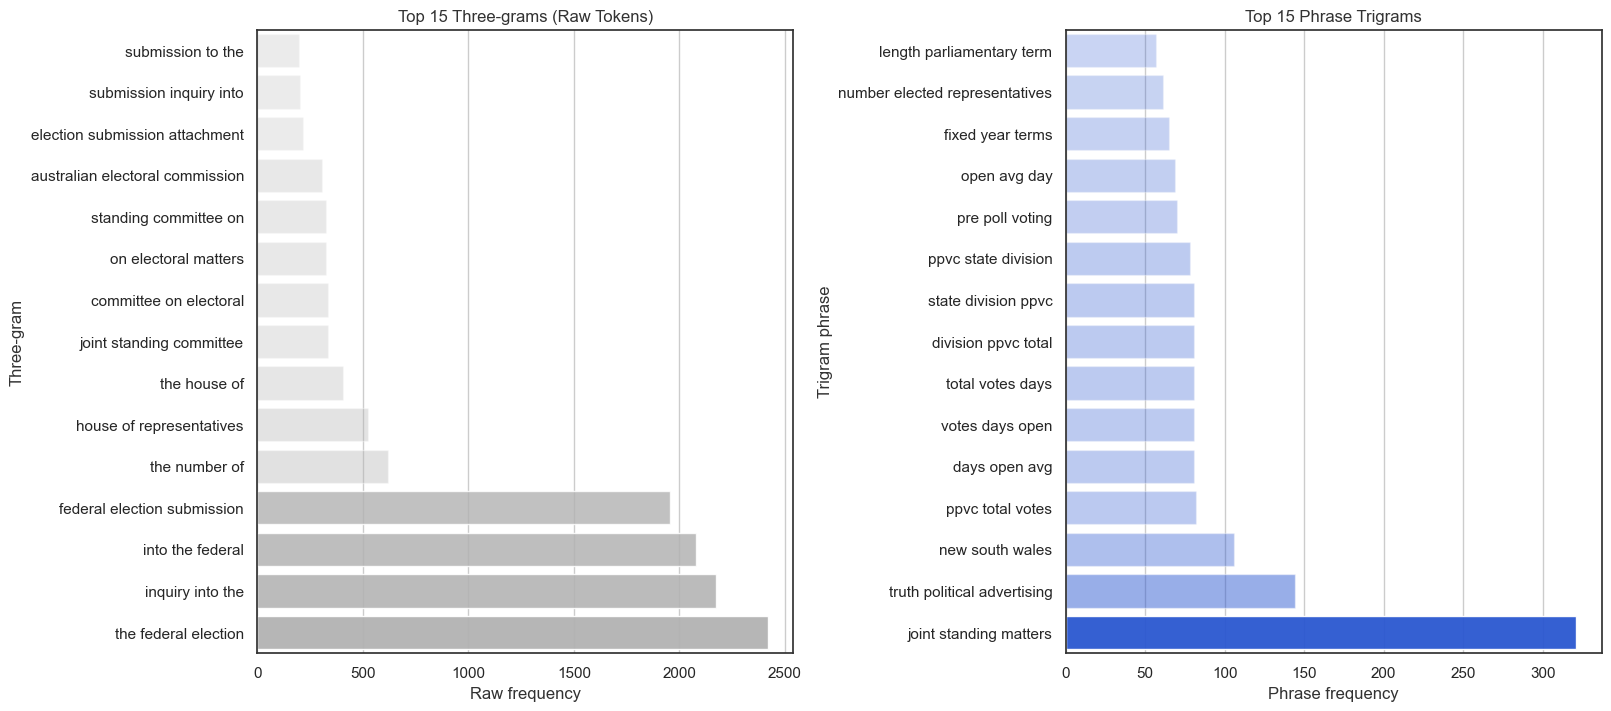

In [63]:
# 4.8 Visual: top three grams

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_trigrams.sort_values("count", ascending=True),
    x="count",
    y="trigram",
    color=UTS_PALETTE["mid_grey"],
    title="Top 15 Three-grams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Three-gram",
    ax=axes[0],
)

visuals.bar(
    data=top_phrase_trigrams.sort_values("count", ascending=True),
    x="count",
    y="trigram",
    color=UTS_PALETTE["blue"],
    title="Top 15 Phrase Trigrams",
    xlabel="Phrase frequency",
    ylabel="Trigram phrase",
    ax=axes[1],
)

plt.show()

The trigram visual now complements the bigram analysis by highlighting higher-order phrase patterns for interpretation.


<a id="49-initial-preprocessing-interpretation"></a>

### 4.9 Initial preprocessing interpretation

At this point in the notebook, the corpus contains **299 submissions** with text successfully extracted from all files. Document lengths remain highly variable after preprocessing, with a median raw length of roughly **815 words**, and organisation submissions generally appearing much longer than individual and withheld name submissions.

The cleaned corpus vocabulary is broad (about **16.7k unique tokens**) and the median lexical diversity is around **0.66**, which suggests that the submissions are not repeating the exact same language even when they discuss related issues. High frequency terms and phrases such as *political*, *voters*, *AEC*, *house representatives*, and *political advertising* indicate that institutional process, electoral administration, and campaign regulation are already emerging as dominant themes.

**Story so far.** The corpus is large enough, varied enough, and linguistically rich enough to justify moving from descriptive analysis into modeling. The next section therefore shifts from asking "what words are common?" to asking "what broader themes and document groupings can we uncover?"


<a id="410-word-cloud-of-preprocessed-corpus"></a>

### 4.10 Word cloud of preprocessed corpus

This visual summary highlights the relative prominence of terms in the fully preprocessed corpus.

A **word cloud** is a communication oriented visualization: larger words appear more prominent, but the chart is approximate rather than exact. It works well as a storytelling device at the end of the preprocessing section because it gives a quick visual impression of the vocabulary before the notebook moves into formal modeling.

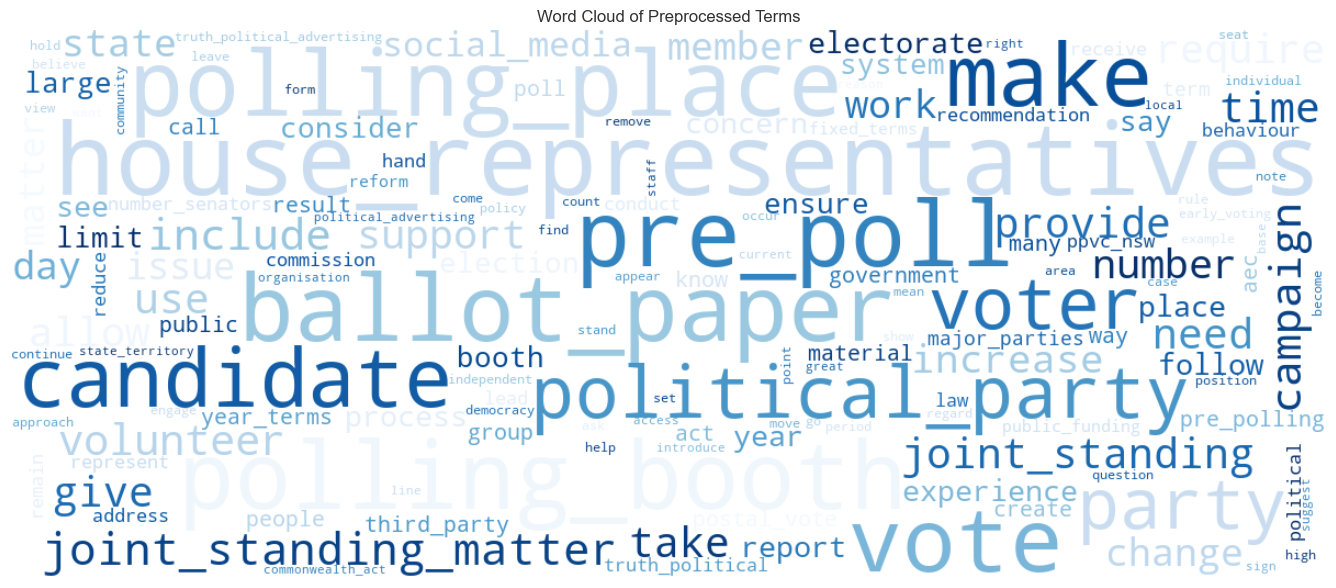

In [64]:
# 4.10 Word cloud

wordcloud_text = " ".join(corpus_df["preprocessed_text"].fillna(""))

visuals.wordcloud(
    text=wordcloud_text,
    title="Word Cloud of Preprocessed Terms",
    width=1200,
    height=500,
    max_words=150,
    colormap="Blues",
    background_color=UTS_PALETTE["white"],
    figsize=(14, 6),
)

Unlike the ranked bar charts, the word cloud gives a quick holistic sense of vocabulary prominence and thematic concentration across the preprocessed corpus. It works well as a visual summary because the reader can immediately see which ideas occupy the largest share of the lexical space.

**Why this matters.** The word cloud is strongest as a communication tool rather than a measurement tool. It helps close the preprocessing section with an intuitive visual impression of the corpus, while the more precise interpretation still comes from the ranked frequency tables and bar charts.



<a id="5-advanced-methods-topic-modeling-and-clustering"></a>

## 5. Advanced Methods (Topic Modeling and Clustering)

This section extends the descriptive analysis with topic modeling and unsupervised clustering so the corpus can be compared through latent themes, document groupings, and broader patterns of policy discussion.

**Why this section is needed.** Frequency charts are useful, but they mostly tell us which words and phrases are common. They do not automatically tell us how those terms combine into broader themes or which submissions are similar to one another overall. That is where topic modeling and clustering become helpful.

**Core concepts introduced here:**
**LDA topic modeling** estimates hidden themes by finding groups of words that tend to appear together across documents.
**TF IDF** gives more weight to terms that help distinguish one document from another.
**Clustering** groups documents that are similar in vocabulary or semantic profile.
**Dimensionality reduction** simplifies high dimensional text features so they can be modeled and visualized more clearly.
**UMAP** projects complex document relationships into two dimensions for an interpretable map like view.

<a id="51-document-vectorization-from-lemmatized-tokens"></a>

### 5.1 Document Vectorization from Lemmatized Tokens

This section builds three separate document-level feature representations from `corpus_df["lemmatized_tokens"]`:

1. Bag of Words counts (`X_bow_counts`)
2. TF-IDF (`X_tfidf`)
3. Continuous Bag of Words Word2Vec document embeddings (`X_cbow_w2v`)


In [65]:
# Prepare corpus text from the existing lemmatized token column
lemmatized_docs = corpus_df["lemmatized_tokens"].tolist()
vectorization_texts = corpus_df["lemmatized_tokens"].apply(" ".join).tolist()

print(f"Documents available for vectorization: {len(vectorization_texts)}")
print(f"Example document text: {vectorization_texts[0][:140]}...")

Documents available for vectorization: 276
Example document text: time revisit territory representation introduction act senate anomalous arrangement year enrolment increase size state remain unchanged terr...


In [66]:
# 1) Bag of Words (raw token counts)
bow_vectorizer = CountVectorizer(max_df=0.9,min_df=3)
X_bow_counts = bow_vectorizer.fit_transform(vectorization_texts)
bow_feature_names = bow_vectorizer.get_feature_names_out()

print("BoW matrix shape:", X_bow_counts.shape)
print("BoW vocabulary size:", len(bow_feature_names))

BoW matrix shape: (276, 6882)
BoW vocabulary size: 6882


In [67]:
# 2) TF-IDF weighting
tfidf_vectorizer = TfidfVectorizer(max_df=0.9, min_df=3)
X_tfidf = tfidf_vectorizer.fit_transform(vectorization_texts)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", X_tfidf.shape)
print("TF-IDF vocabulary size:", len(tfidf_feature_names))

TF-IDF matrix shape: (276, 6882)
TF-IDF vocabulary size: 6882


In [68]:
# 3) Continuous Bag of Words (CBOW) Word2Vec document embeddings
from gensim.models import Word2Vec

cbow_w2v_model = Word2Vec(
    sentences=lemmatized_docs,
    vector_size=100,
    window=5,
    min_count=3,
    workers=1,
    sg=0,  # CBOW architecture
    seed=42,
)

def document_embedding(tokens, model):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if not vectors:
        return np.zeros(model.vector_size, dtype=float)
    return np.mean(vectors, axis=0)

X_cbow_w2v = np.vstack([document_embedding(tokens, cbow_w2v_model) for tokens in lemmatized_docs])

print("CBOW Word2Vec matrix shape:", X_cbow_w2v.shape)
print("CBOW embedding dimension:", cbow_w2v_model.vector_size)
print("CBOW vocabulary size:", len(cbow_w2v_model.wv))

2026-03-14 08:06:53,404 | INFO | collecting all words and their counts
2026-03-14 08:06:53,404 | INFO | PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-14 08:06:53,462 | INFO | collected 236224 word types from a corpus of 381753 raw words and 276 sentences
2026-03-14 08:06:53,463 | INFO | Creating a fresh vocabulary
2026-03-14 08:06:53,498 | INFO | Word2Vec lifecycle event {'msg': 'effective_min_count=3 retains 11242 unique words (4.76% of original 236224, drops 224982)', 'datetime': '2026-03-14T08:06:53.498570', 'gensim': '4.4.0', 'python': '3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]', 'platform': 'macOS-26.1-arm64-arm-64bit', 'event': 'prepare_vocab'}
2026-03-14 08:06:53,499 | INFO | Word2Vec lifecycle event {'msg': 'effective_min_count=3 leaves 143395 word corpus (37.56% of original 381753, drops 238358)', 'datetime': '2026-03-14T08:06:53.499188', 'gensim': '4.4.0', 'python': '3.12.8 (v3.12.8:2dc476bcb91, Dec  3 

CBOW Word2Vec matrix shape: (276, 100)
CBOW embedding dimension: 100
CBOW vocabulary size: 11242



<a id="52-lda-topic-modeling-with-bag-of-words"></a>

### 5.2 LDA Topic Modeling with Bag-of-Words

This cell evaluates candidate topic counts with a coherence score, selects the strongest LDA solution, and summarizes each topic using high probability terms.

**What is LDA?** Latent Dirichlet Allocation (LDA) is a topic modeling method that treats each document as a mixture of topics and each topic as a mixture of words. It does not assign one fixed label to a document by itself; instead, it estimates probabilities that indicate how strongly each topic appears in each submission.

**What is coherence?** Topic coherence is a quality check that estimates whether the top words in a topic make semantic sense together. In this notebook, coherence is used to compare several candidate topic counts so the final model is selected on an interpretable basis rather than by guesswork.

2026-03-14 08:06:56,214 | INFO | adding document #0 to Dictionary<0 unique tokens: []>
2026-03-14 08:06:56,555 | INFO | built Dictionary<236224 unique tokens: ['accept', 'accepted_timetable_act', 'act', 'act_enrolment_increased', 'act_greater_increase']...> from 276 documents (total 381753 corpus positions)
2026-03-14 08:06:56,555 | INFO | Dictionary lifecycle event {'msg': "built Dictionary<236224 unique tokens: ['accept', 'accepted_timetable_act', 'act', 'act_enrolment_increased', 'act_greater_increase']...> from 276 documents (total 381753 corpus positions)", 'datetime': '2026-03-14T08:06:56.555898', 'gensim': '4.4.0', 'python': '3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]', 'platform': 'macOS-26.1-arm64-arm-64bit', 'event': 'created'}
2026-03-14 08:06:56,568 | INFO | using ParallelWordOccurrenceAccumulator<processes=7, batch_size=64> to estimate probabilities from sliding windows
2026-03-14 08:07:02,775 | INFO | 1 batches submitted to acc

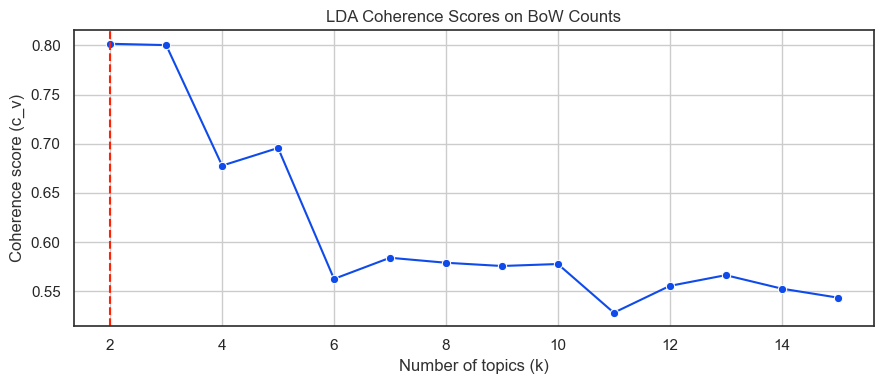

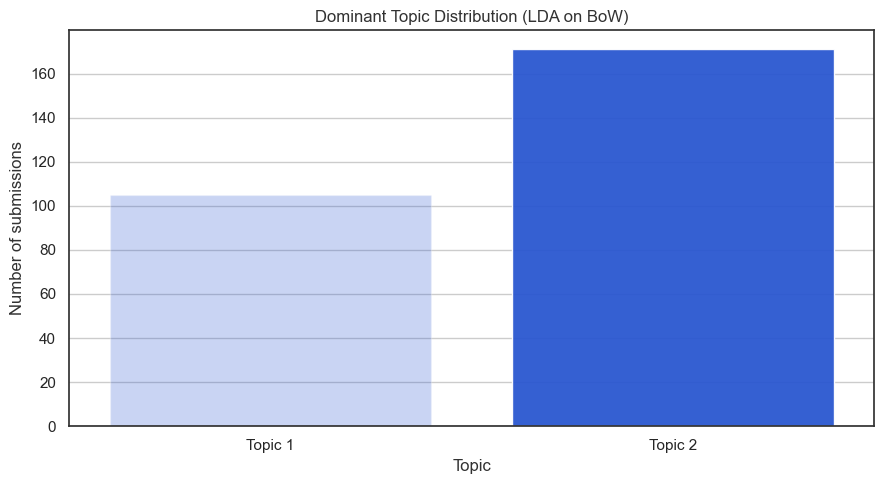

,k,coherence_score
0,2,0.801574
1,3,0.800232
2,4,0.677695
3,5,0.695644
4,6,0.562556
5,7,0.584038
6,8,0.578970
7,9,0.575667
8,10,0.577681
9,11,0.528166


,topic,top_terms
0,Topic 1,"house_representatives, political_party, ballot..."
1,Topic 2,"pre_poll, polling_booth, polling_place, volunt..."


In [69]:
# 5.2 LDA topic modeling using the Bag-of-Words count matrix

# Reuse the BoW matrix prepared at the start of Section 5
bow_dtm = X_bow_counts
bow_feature_names = bow_vectorizer.get_feature_names_out()

topic_candidates = list(range(2, 16))
coherence_rows = []
lda_candidates = {}

for k in topic_candidates:
    candidate_model = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method="batch",
        max_iter=25,
    )
    candidate_model.fit(bow_dtm)
    lda_candidates[k] = candidate_model
    coherence_rows.append(
        {
            "k": k,
            "coherence_score": TextAnalytics.get_coherence_score(lemmatized_docs, candidate_model, bow_feature_names),
        }
    )

coherence_df = pd.DataFrame(coherence_rows)
n_topics = int(coherence_df.sort_values(["coherence_score", "k"], ascending=[False, True]).iloc[0]["k"])
lda_model = lda_candidates[n_topics]
topic_distributions = lda_model.transform(bow_dtm)

corpus_df["dominant_topic"] = topic_distributions.argmax(axis=1) + 1
topic_terms_df = TextAnalytics.extract_top_terms_per_topic(lda_model, bow_feature_names, top_n=10)

LOGGER.debug(
    "LDA fitted on BoW counts: topics=%d, vocab=%d, coherence=%.4f",
    n_topics,
    len(bow_feature_names),
    coherence_df.loc[coherence_df["k"] == n_topics, "coherence_score"].iloc[0],
)

plt.figure(figsize=(9, 4))
sns.lineplot(data=coherence_df, x="k", y="coherence_score", marker="o", color=UTS_PALETTE["blue"])
plt.axvline(n_topics, color=UTS_PALETTE["red"], linestyle="--", linewidth=1.5)
plt.title("LDA Coherence Scores on BoW Counts")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence score (c_v)")
plt.tight_layout()
plt.show()

topic_counts = (
    corpus_df["dominant_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("topic")
    .reset_index(name="count")
)

topic_counts["topic"] = topic_counts["topic"].astype(str).radd("Topic ")
visuals.bar(
    data=topic_counts,
    x="topic",
    y="count",
    color=UTS_PALETTE["blue"],
    title="Dominant Topic Distribution (LDA on BoW)",
    xlabel="Topic",
    ylabel="Number of submissions",
    figsize=(9, 5),
)

display(coherence_df)
display(topic_terms_df)

The coherence curve compares several candidate topic counts and marks the selected solution with a vertical line. In this run, the chosen model is the one with the strongest coherence score, meaning its top words form the most semantically consistent combination among the tested options.

**Why this matters.** A topic model is only useful if its topics make human sense. Using coherence as a selection rule makes the LDA result easier to justify and easier to explain to a non-technical reader.

<a id="53-tf-idf-clustering-experiment-hierarchical-k-means"></a>

### 5.3 TF-IDF Clustering Experiment (Hierarchical + K-means)

This section applies hierarchical clustering and K-means on TF-IDF features to identify document groupings and compare cluster structure across methods.

The key concept here is **feature-weighted similarity**: TF-IDF emphasizes terms that distinguish documents, so clusters reflect topical separation rather than only frequent generic vocabulary.


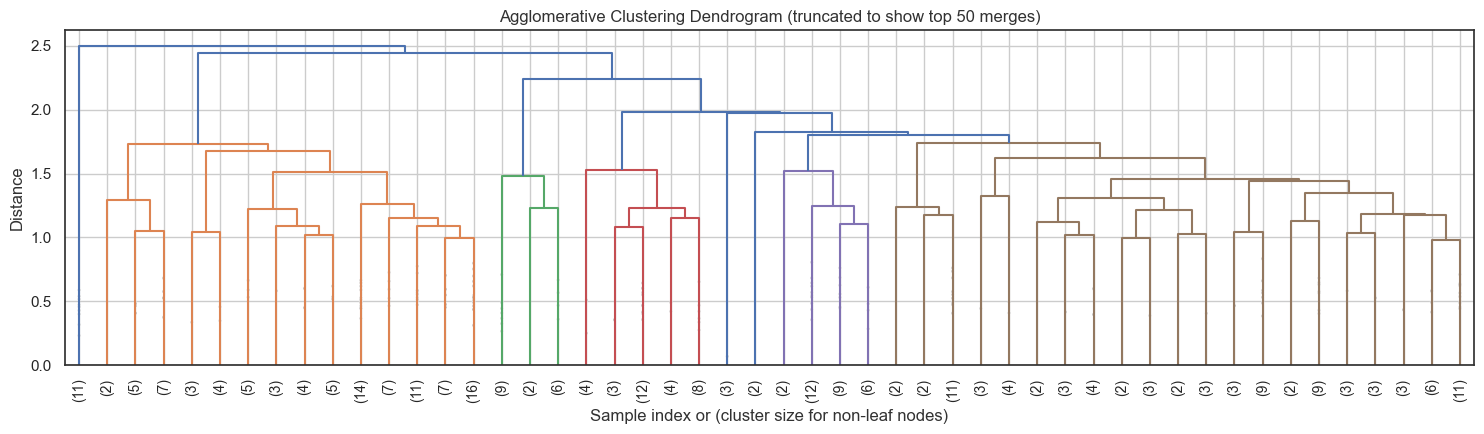

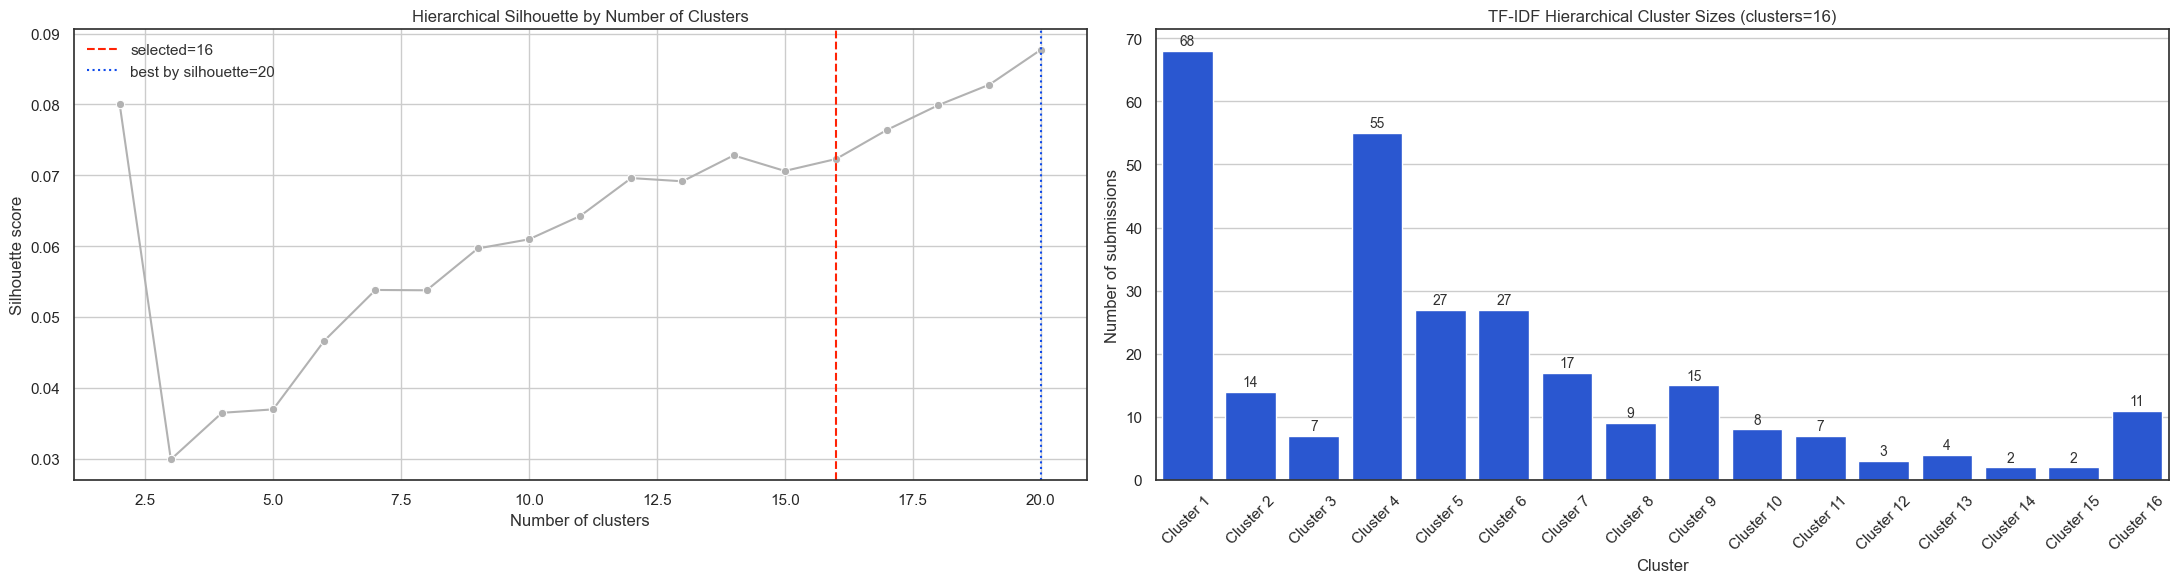

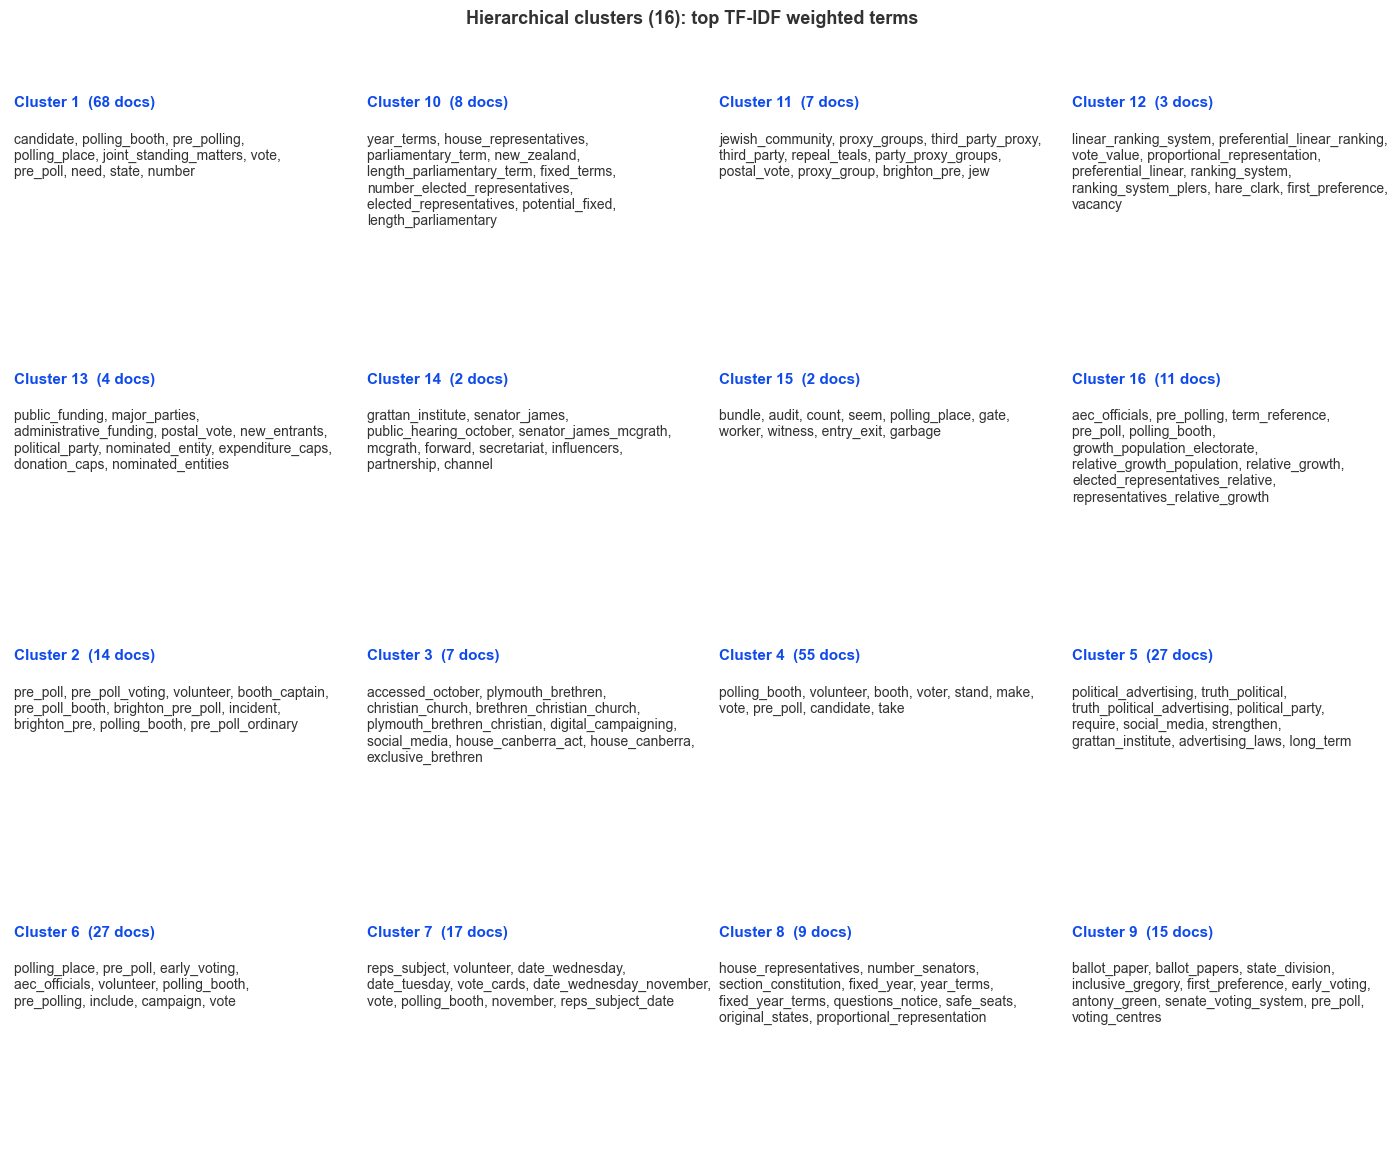

In [70]:
# 5.3A TF-IDF hierarchical clustering
def top_tokens_from_cluster_assignments(token_docs, labels, top_n=12):
    rows = []
    for cluster_id in sorted(np.unique(labels)):
        doc_indices = np.where(labels == cluster_id)[0]
        token_counter = Counter(token for doc_idx in doc_indices for token in token_docs[doc_idx])
        rows.append(
            {
                "cluster": f"Cluster {cluster_id + 1}",
                "n_docs": len(doc_indices),
                "top_terms": ", ".join([token for token, _ in token_counter.most_common(top_n)]),
            }
        )
    return pd.DataFrame(rows)

def print_cluster_summary(title, terms_df):
    print(f"\n{title}")
    has_n_docs = "n_docs" in terms_df.columns
    for _, row in terms_df.sort_values("cluster").iterrows():
        if has_n_docs and pd.notna(row["n_docs"]):
            print(f"- {row['cluster']} ({int(row['n_docs'])} docs)")
        else:
            print(f"- {row['cluster']}")
        print(f"  {row['top_terms']}")

def plot_cluster_term_cards(title, terms_df, n_cols=2):
    terms_df = terms_df.sort_values("cluster").reset_index(drop=True)
    has_n_docs = "n_docs" in terms_df.columns
    n_items = len(terms_df)
    n_rows = int(np.ceil(n_items / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.9 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (_, row) in zip(axes, terms_df.iterrows()):
        wrapped_terms = textwrap.fill(row["top_terms"], width=52)
        card_title = str(row["cluster"])
        if has_n_docs and pd.notna(row["n_docs"]):
            card_title = f"{card_title}  ({int(row['n_docs'])} docs)"
        ax.text(
            0.02,
            0.92,
            card_title,
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top",
            color=UTS_PALETTE["blue"],
        )
        ax.text(0.02, 0.78, wrapped_terms, transform=ax.transAxes, fontsize=10, va="top")
        ax.axis("off")

    for ax in axes[n_items:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

# Use the TF-IDF matrix already created in Section 5 vectorization
n_tfidf_components = max(2, min(50, X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1))
tfidf_svd = TruncatedSVD(n_components=n_tfidf_components, random_state=42)
X_tfidf_reduced = tfidf_svd.fit_transform(X_tfidf)

# Evaluate number of clusters (cluster_num) up to 20, select 16 as the final value
tfidf_hier_cluster_num_candidates = list(range(2, 21))
tfidf_hier_eval = []
for cluster_num in tfidf_hier_cluster_num_candidates:
    labels = AgglomerativeClustering(n_clusters=cluster_num, linkage="ward").fit_predict(X_tfidf_reduced)
    tfidf_hier_eval.append(
        {
            "cluster_num": cluster_num,
            "silhouette_score": silhouette_score(X_tfidf_reduced, labels),
        }
    )

tfidf_hier_eval_df = pd.DataFrame(tfidf_hier_eval)
tfidf_hier_auto_best_cluster_num = int(tfidf_hier_eval_df.loc[tfidf_hier_eval_df["silhouette_score"].idxmax(), "cluster_num"])
tfidf_hier_selected_cluster_num = 16  # FINAL NUMBER OF CLUSTERS

tfidf_hier_labels = AgglomerativeClustering(n_clusters=tfidf_hier_selected_cluster_num, linkage="ward").fit_predict(X_tfidf_reduced)
corpus_df["tfidf_hierarchical_cluster"] = tfidf_hier_labels + 1

tfidf_hier_counts = (
    corpus_df["tfidf_hierarchical_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
tfidf_hier_counts["cluster"] = tfidf_hier_counts["cluster"].astype(str).radd("Cluster ")

tfidf_hier_top_terms_tfidf = TextAnalytics.extract_top_terms_per_cluster(
    X_tfidf,
    tfidf_hier_labels,
    tfidf_feature_names,
    top_n=10,
)

tfidf_hier_top_terms_tokens = top_tokens_from_cluster_assignments(
    lemmatized_docs,
    tfidf_hier_labels,
    top_n=12,
)

LOGGER.debug(
    "TF-IDF hierarchical clustering complete: docs=%d, features=%d, clusters=%d",
    len(corpus_df),
    len(tfidf_feature_names),
    tfidf_hier_selected_cluster_num,
)

# Dendrogram plot
plt.figure(figsize=(15, 4.5))
plt.title("Agglomerative Clustering Dendrogram (truncated to show top 50 merges)")
Z = linkage(X_tfidf_reduced, method='ward')
dendrogram(
    Z,
    truncate_mode="lastp",
    p=50,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
)
plt.xlabel("Sample index or (cluster size for non-leaf nodes)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Plots for silhouette and cluster sizes (WIDE for cluster label clarity)
fig, axes = plt.subplots(1, 2, figsize=(22, 6))  # Make wider to see cluster labels

sns.lineplot(
    data=tfidf_hier_eval_df,
    x="cluster_num",
    y="silhouette_score",
    marker="o",
    ax=axes[0],
    color=UTS_PALETTE["mid_grey"],
)
axes[0].axvline(tfidf_hier_selected_cluster_num, color=UTS_PALETTE["red"], linestyle="--", label=f"selected={tfidf_hier_selected_cluster_num}")
axes[0].axvline(
    tfidf_hier_auto_best_cluster_num,
    color=UTS_PALETTE["blue"],
    linestyle=":",
    label=f"best by silhouette={tfidf_hier_auto_best_cluster_num}",
)
axes[0].set_title("Hierarchical Silhouette by Number of Clusters")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Silhouette score")
axes[0].legend(frameon=False)

sns.barplot(data=tfidf_hier_counts, x="cluster", y="count", color=UTS_PALETTE["blue"], ax=axes[1])
axes[1].set_title(f"TF-IDF Hierarchical Cluster Sizes (clusters={tfidf_hier_selected_cluster_num})")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Number of submissions")
for container in axes[1].containers:
    axes[1].bar_label(container, padding=2, fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plot_cluster_term_cards(
    f"Hierarchical clusters ({tfidf_hier_selected_cluster_num}): top TF-IDF weighted terms",
    tfidf_hier_top_terms_tfidf,
    n_cols=4
)

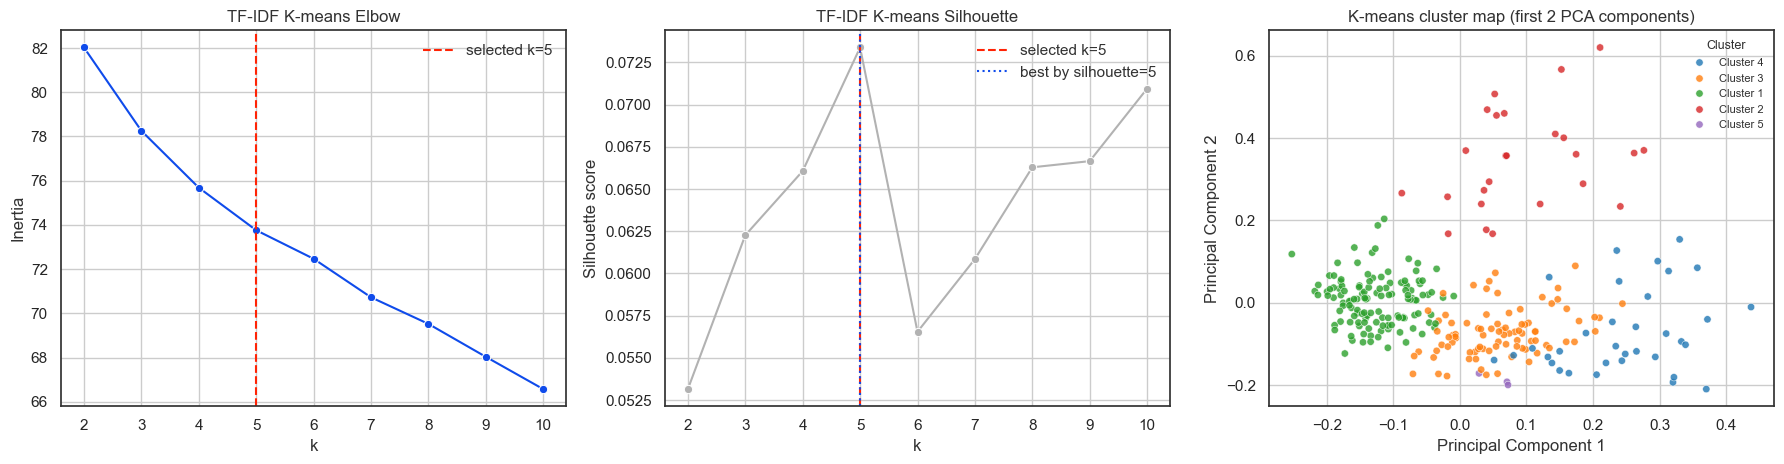

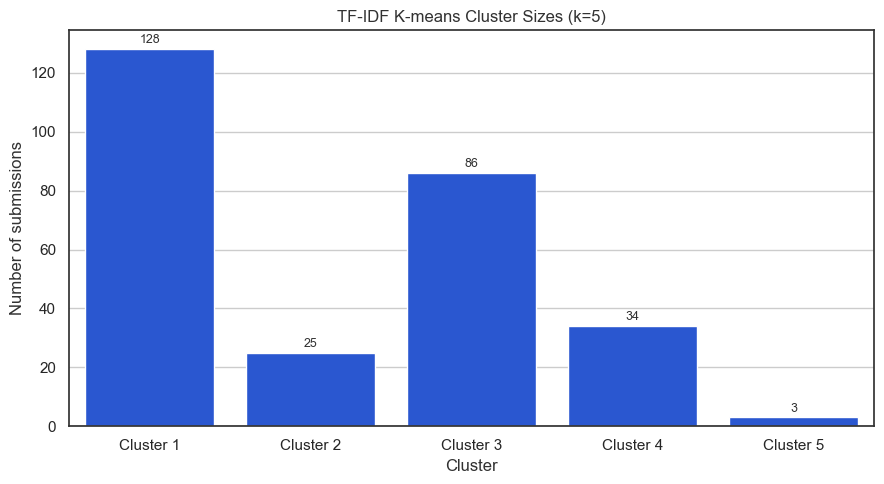

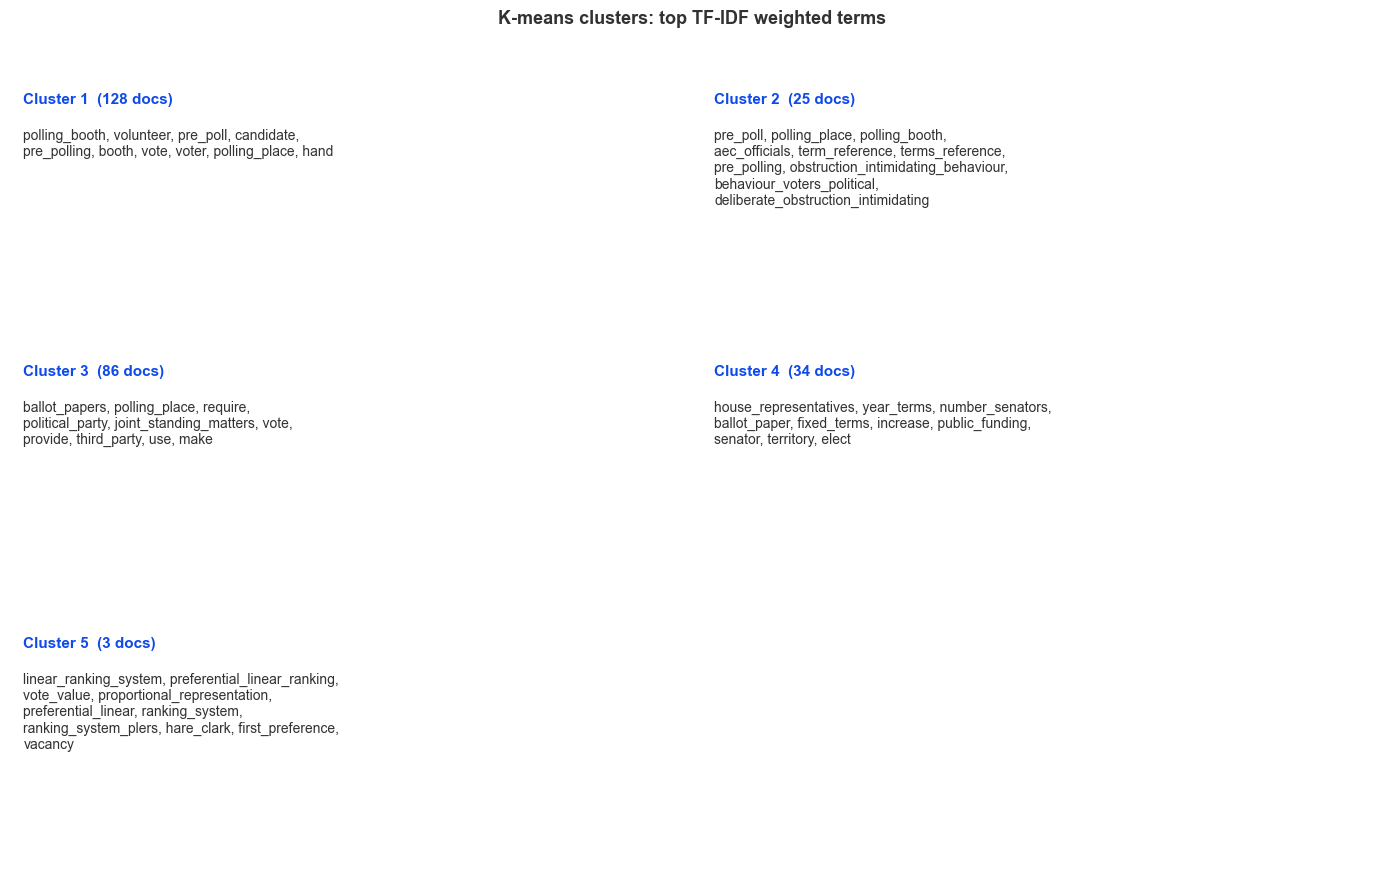

In [75]:
# 5.3B TF-IDF K-means clustering

from sklearn.decomposition import PCA

# Evaluate candidate k values up to 10, but force the selected value to k=5
k_candidates = list(range(2, 11))
tfidf_kmeans_eval = []
tfidf_kmeans_label_map = {}

for k in k_candidates:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_tfidf_reduced)
    tfidf_kmeans_label_map[k] = labels
    tfidf_kmeans_eval.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette_score(X_tfidf_reduced, labels),
        }
    )

tfidf_kmeans_eval_df = pd.DataFrame(tfidf_kmeans_eval)
tfidf_auto_best_k = int(tfidf_kmeans_eval_df.loc[tfidf_kmeans_eval_df["silhouette_score"].idxmax(), "k"])
tfidf_best_k = 5

if tfidf_best_k not in tfidf_kmeans_label_map:
    raise ValueError("Selected tfidf_best_k is not in evaluated k_candidates")

tfidf_kmeans_labels = tfidf_kmeans_label_map[tfidf_best_k]
corpus_df["tfidf_kmeans_cluster"] = tfidf_kmeans_labels + 1

tfidf_kmeans_counts = (
    corpus_df["tfidf_kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
tfidf_kmeans_counts["cluster"] = tfidf_kmeans_counts["cluster"].astype(str).radd("Cluster ")

tfidf_kmeans_top_terms_tfidf = TextAnalytics.extract_top_terms_per_cluster(
    X_tfidf,
    tfidf_kmeans_labels,
    tfidf_feature_names,
    top_n=10,
)

tfidf_kmeans_top_terms_tokens = top_tokens_from_cluster_assignments(
    lemmatized_docs,
    tfidf_kmeans_labels,
    top_n=12,
)

# 2D map for visual intuition of cluster separation - use PCA instead of SVD slice
pca = PCA(n_components=2, random_state=42)
X_tfidf_pca = pca.fit_transform(X_tfidf)

tfidf_plot_df = pd.DataFrame(X_tfidf_pca, columns=["PC1", "PC2"])
tfidf_plot_df["cluster"] = corpus_df["tfidf_kmeans_cluster"].astype(str).radd("Cluster ")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

sns.lineplot(data=tfidf_kmeans_eval_df, x="k", y="inertia", marker="o", ax=axes[0], color=UTS_PALETTE["blue"])
axes[0].axvline(tfidf_best_k, color=UTS_PALETTE["red"], linestyle="--", label="selected k=5")
axes[0].set_title("TF-IDF K-means Elbow")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].legend(frameon=False)

sns.lineplot(data=tfidf_kmeans_eval_df, x="k", y="silhouette_score", marker="o", ax=axes[1], color=UTS_PALETTE["mid_grey"])
axes[1].axvline(tfidf_best_k, color=UTS_PALETTE["red"], linestyle="--", label="selected k=5")
axes[1].axvline(tfidf_auto_best_k, color=UTS_PALETTE["blue"], linestyle=":", label=f"best by silhouette={tfidf_auto_best_k}")
axes[1].set_title("TF-IDF K-means Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].legend(frameon=False)

sns.scatterplot(
    data=tfidf_plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=28,
    alpha=0.8,
    ax=axes[2],
)
axes[2].set_title("K-means cluster map (first 2 PCA components)")
axes[2].set_xlabel("Principal Component 1")
axes[2].set_ylabel("Principal Component 2")
axes[2].legend(title="Cluster", fontsize=8, title_fontsize=9, frameon=False, loc="best")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=tfidf_kmeans_counts, x="cluster", y="count", color=UTS_PALETTE["blue"], ax=ax)
ax.set_title("TF-IDF K-means Cluster Sizes (k=5)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of submissions")
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)
plt.tight_layout()
plt.show()

plot_cluster_term_cards(
    "K-means clusters: top TF-IDF weighted terms",
    tfidf_kmeans_top_terms_tfidf,
)


This experiment runs both hierarchical clustering and K-means on TF-IDF features. The TF-IDF weighted top terms show which n-grams define each cluster in vector space, while the backward token mapping shows the most common original lemmatized tokens inside each assigned cluster.

<a id="54-word2vec-clustering-experiment-hierarchical-k-means"></a>

### 5.4 Word2Vec Clustering Experiment (Hierarchical + K-means)

This section clusters CBOW Word2Vec document embeddings with hierarchical clustering and K-means, then interprets clusters using token back-mapping.

**What these concepts mean:**
**Word2Vec embeddings** represent semantic context in dense vectors rather than sparse term counts.
**K-means** assigns documents to fixed cluster centroids, while **hierarchical clustering** reveals nested similarity structure.

This complements TF-IDF by testing whether semantic embeddings produce coherent clusters beyond frequency-based weighting.


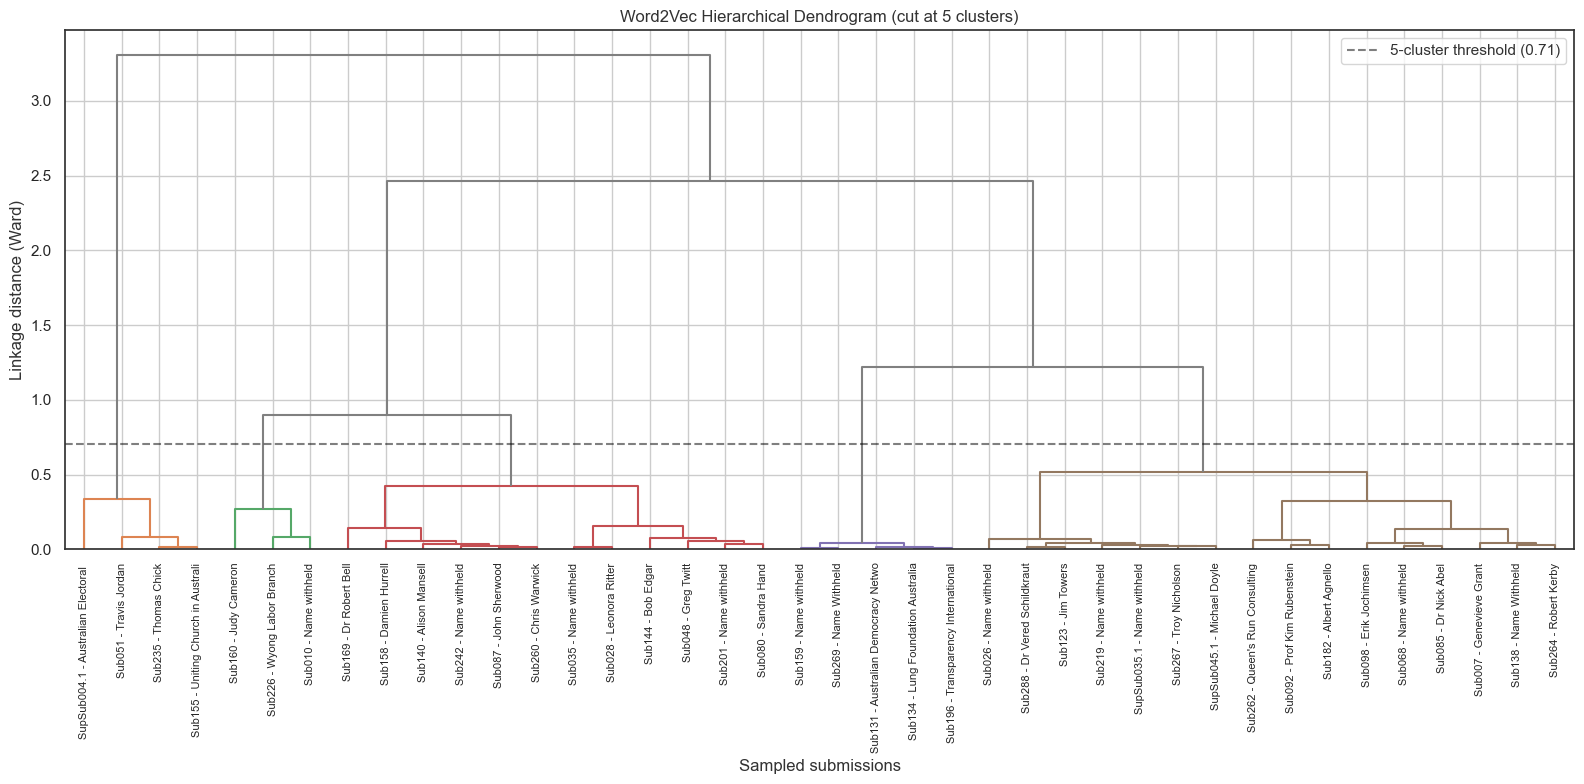

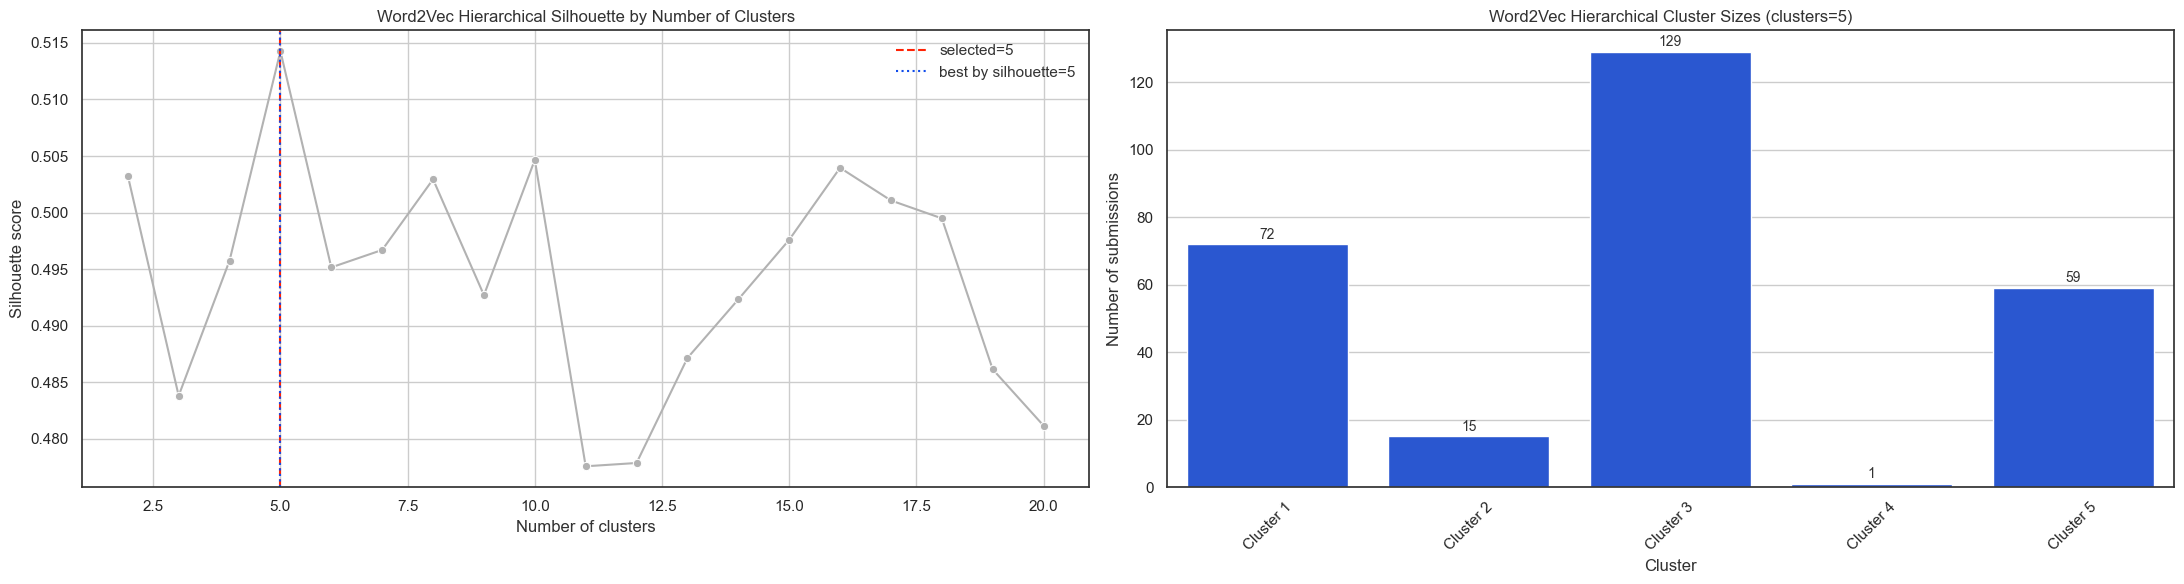

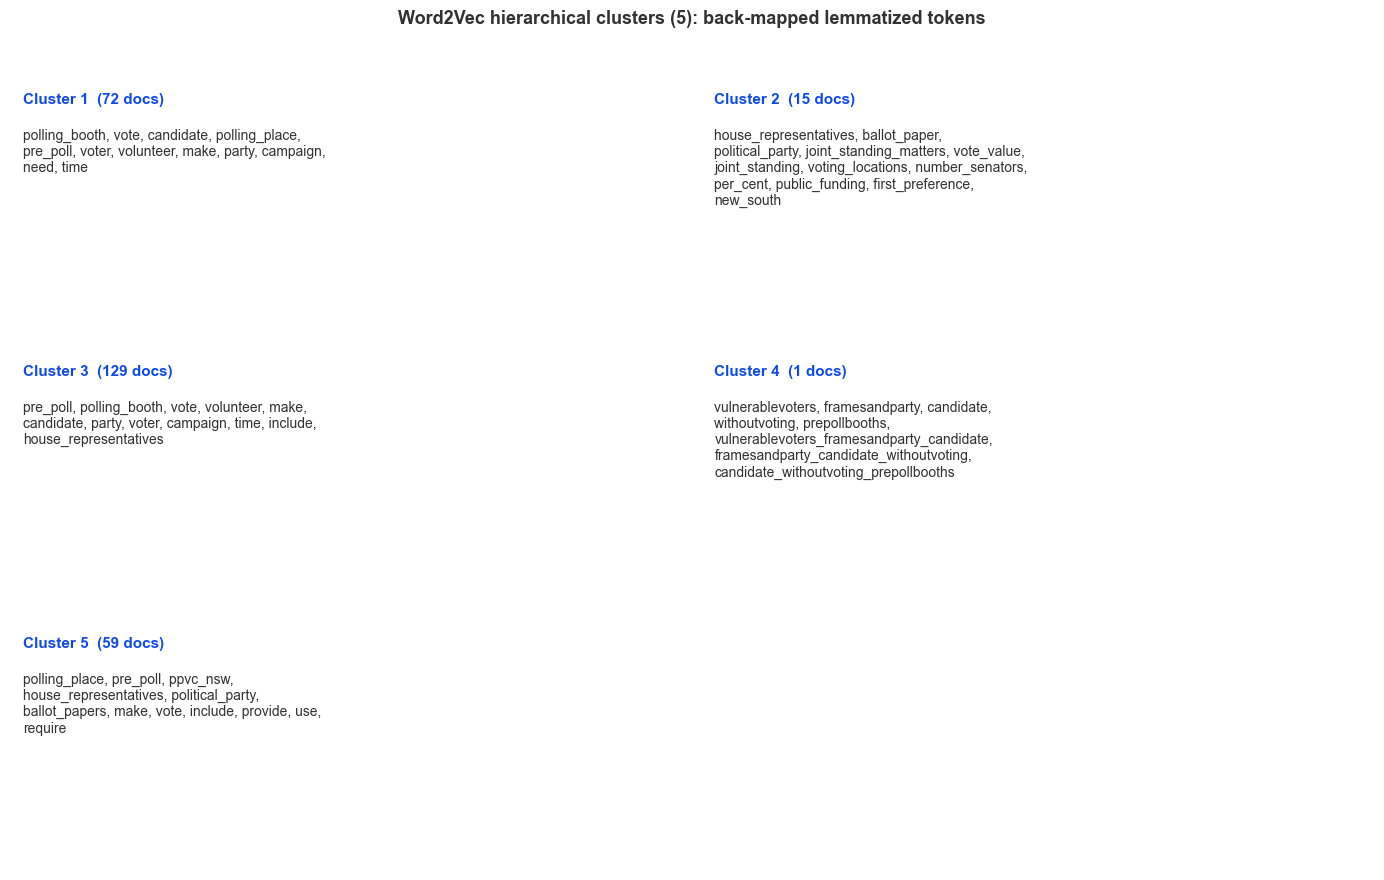


Word2Vec hierarchical clusters (selected=5, auto-best by silhouette=5):
- Cluster 1 (72 docs)
  polling_booth, vote, candidate, polling_place, pre_poll, voter, volunteer, make, party, campaign, need, time
- Cluster 2 (15 docs)
  house_representatives, ballot_paper, political_party, joint_standing_matters, vote_value, joint_standing, voting_locations, number_senators, per_cent, public_funding, first_preference, new_south
- Cluster 3 (129 docs)
  pre_poll, polling_booth, vote, volunteer, make, candidate, party, voter, campaign, time, include, house_representatives
- Cluster 4 (1 docs)
  vulnerablevoters, framesandparty, candidate, withoutvoting, prepollbooths, vulnerablevoters_framesandparty_candidate, framesandparty_candidate_withoutvoting, candidate_withoutvoting_prepollbooths
- Cluster 5 (59 docs)
  polling_place, pre_poll, ppvc_nsw, house_representatives, political_party, ballot_papers, make, vote, include, provide, use, require


In [72]:
# 5.4A Word2Vec hierarchical clustering

X_w2v = X_cbow_w2v

w2v_hier_cluster_num_candidates = list(range(2, 21))
w2v_hier_eval = []
for cluster_num in w2v_hier_cluster_num_candidates:
    labels = AgglomerativeClustering(n_clusters=cluster_num, linkage="ward").fit_predict(X_w2v)
    w2v_hier_eval.append(
        {
            "cluster_num": cluster_num,
            "silhouette_score": silhouette_score(X_w2v, labels),
        }
    )

w2v_hier_eval_df = pd.DataFrame(w2v_hier_eval)
w2v_hier_auto_best_cluster_num = int(
    w2v_hier_eval_df.loc[w2v_hier_eval_df["silhouette_score"].idxmax(), "cluster_num"]
)
w2v_hier_selected_cluster_num = 5

w2v_hier_labels = AgglomerativeClustering(
    n_clusters=w2v_hier_selected_cluster_num, linkage="ward"
).fit_predict(X_w2v)
corpus_df["w2v_hierarchical_cluster"] = w2v_hier_labels + 1

w2v_hier_counts = (
    corpus_df["w2v_hierarchical_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
w2v_hier_counts["cluster"] = w2v_hier_counts["cluster"].astype(str).radd("Cluster ")

w2v_hier_top_terms_tokens = top_tokens_from_cluster_assignments(
    lemmatized_docs,
    w2v_hier_labels,
    top_n=12,
)

LOGGER.debug(
    "Word2Vec hierarchical clustering complete: docs=%d, clusters=%d",
    len(corpus_df),
    w2v_hier_selected_cluster_num,
)

# Dendrogram on a subsample for readability
sample_size = min(40, X_w2v.shape[0])
sample_indices = np.random.RandomState(42).choice(X_w2v.shape[0], size=sample_size, replace=False)
sample_features = X_w2v[sample_indices]
sample_labels = [Path(name).stem[:35] for name in corpus_df.iloc[sample_indices]["file_name"]]

linkage_matrix = linkage(sample_features, method="ward")
threshold = (linkage_matrix[-w2v_hier_selected_cluster_num + 1, 2]
             + linkage_matrix[-w2v_hier_selected_cluster_num, 2]) / 2

plt.figure(figsize=(16, 8))
dendrogram(
    linkage_matrix,
    labels=sample_labels,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=threshold,
    above_threshold_color="grey",
)
plt.axhline(y=threshold, color="black", linestyle="--", alpha=0.5,
            label=f"{w2v_hier_selected_cluster_num}-cluster threshold ({threshold:.2f})")
plt.title(f"Word2Vec Hierarchical Dendrogram (cut at {w2v_hier_selected_cluster_num} clusters)")
plt.xlabel("Sampled submissions")
plt.ylabel("Linkage distance (Ward)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Silhouette curve and cluster sizes
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

sns.lineplot(
    data=w2v_hier_eval_df, x="cluster_num", y="silhouette_score",
    marker="o", ax=axes[0], color=UTS_PALETTE["mid_grey"],
)
axes[0].axvline(w2v_hier_selected_cluster_num, color=UTS_PALETTE["red"], linestyle="--",
                label=f"selected={w2v_hier_selected_cluster_num}")
axes[0].axvline(w2v_hier_auto_best_cluster_num, color=UTS_PALETTE["blue"], linestyle=":",
                label=f"best by silhouette={w2v_hier_auto_best_cluster_num}")
axes[0].set_title("Word2Vec Hierarchical Silhouette by Number of Clusters")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Silhouette score")
axes[0].legend(frameon=False)

sns.barplot(data=w2v_hier_counts, x="cluster", y="count", color=UTS_PALETTE["blue"], ax=axes[1])
axes[1].set_title(f"Word2Vec Hierarchical Cluster Sizes (clusters={w2v_hier_selected_cluster_num})")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Number of submissions")
for container in axes[1].containers:
    axes[1].bar_label(container, padding=2, fontsize=10)
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

plot_cluster_term_cards(
    f"Word2Vec hierarchical clusters ({w2v_hier_selected_cluster_num}): back-mapped lemmatized tokens",
    w2v_hier_top_terms_tokens,
)

print_cluster_summary(
    f"Word2Vec hierarchical clusters (selected={w2v_hier_selected_cluster_num}, "
    f"auto-best by silhouette={w2v_hier_auto_best_cluster_num}):",
    w2v_hier_top_terms_tokens,
)



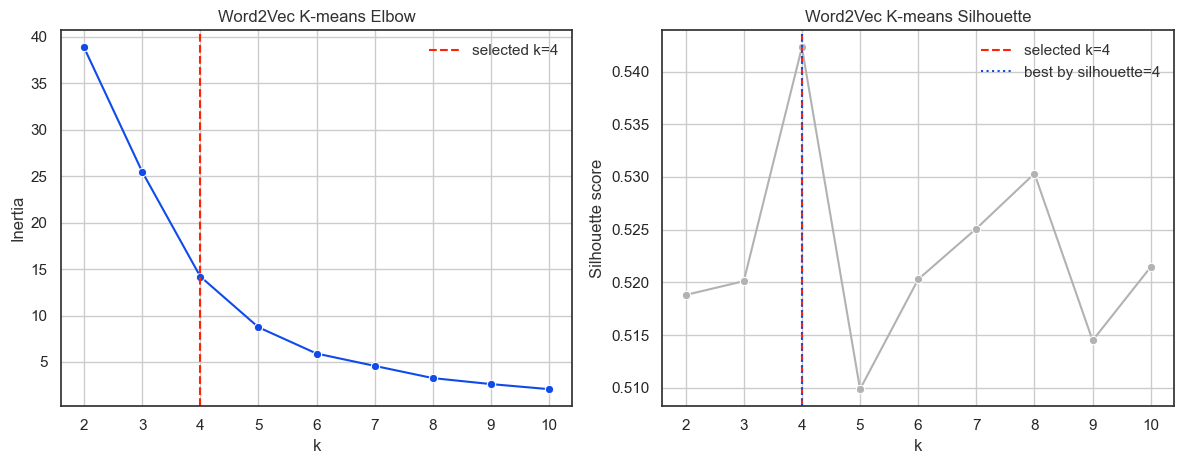

/Users/juansebastianvargastorres/Desktop/UTS_subjects/Semester_2/NLP/nlp-parliamentary-inquiry-text-mining/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


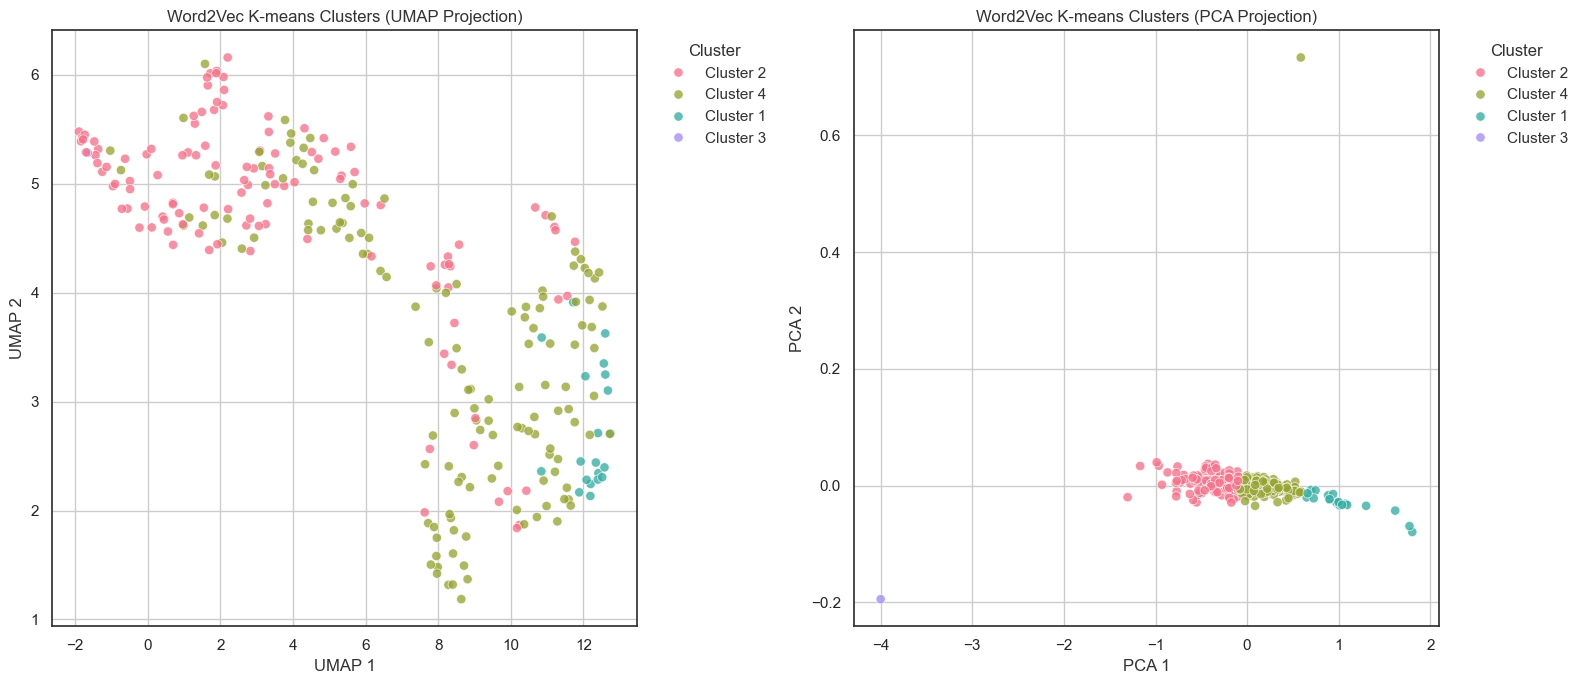

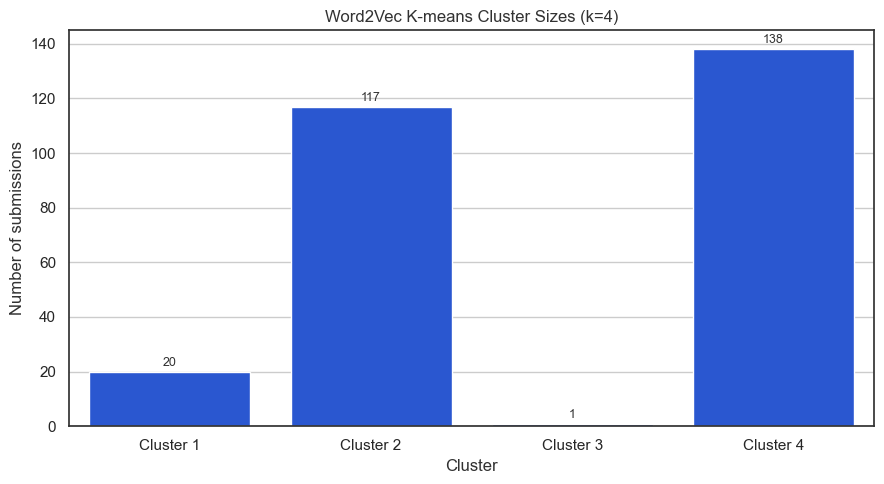

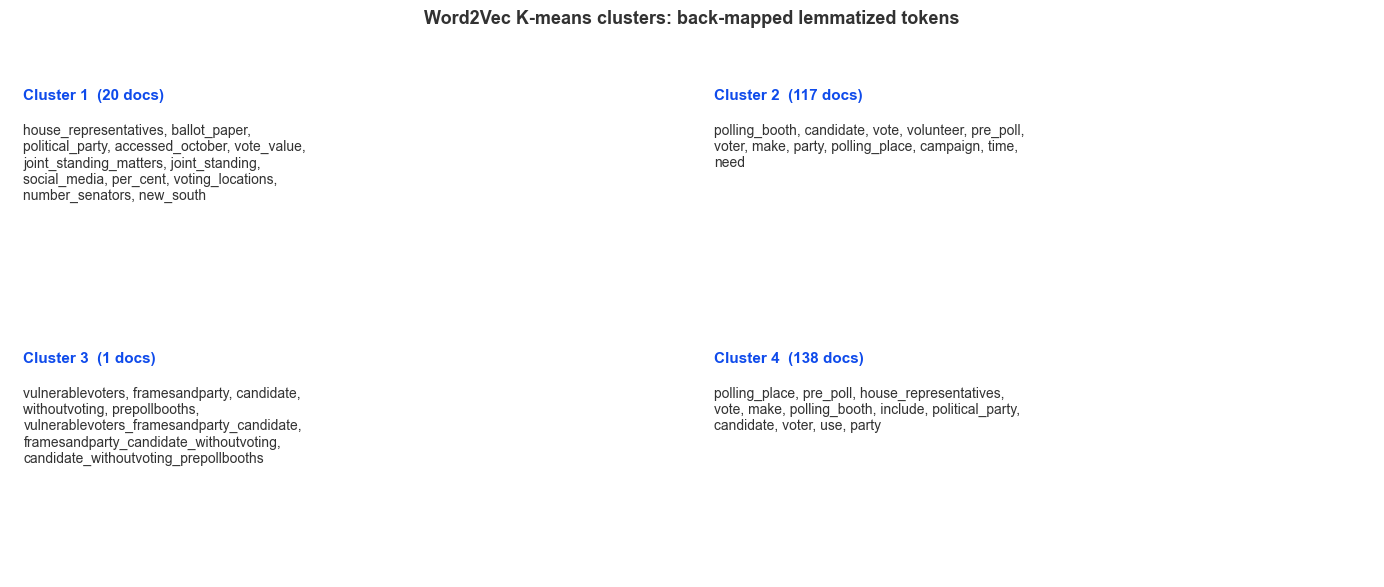


Word2Vec K-means selected k: 4 (auto-best by silhouette was 4)

Word2Vec K-means clusters (back-mapped lemmatized tokens):
- Cluster 1 (20 docs)
  house_representatives, ballot_paper, political_party, accessed_october, vote_value, joint_standing_matters, joint_standing, social_media, per_cent, voting_locations, number_senators, new_south
- Cluster 2 (117 docs)
  polling_booth, candidate, vote, volunteer, pre_poll, voter, make, party, polling_place, campaign, time, need
- Cluster 3 (1 docs)
  vulnerablevoters, framesandparty, candidate, withoutvoting, prepollbooths, vulnerablevoters_framesandparty_candidate, framesandparty_candidate_withoutvoting, candidate_withoutvoting_prepollbooths
- Cluster 4 (138 docs)
  polling_place, pre_poll, house_representatives, vote, make, polling_booth, include, political_party, candidate, voter, use, party


In [74]:
# 5.4B Word2Vec K-means clustering

# Evaluate candidate k values up to 10, but force selected value to k=4
w2v_k_candidates = list(range(2, 11))
w2v_kmeans_eval = []
w2v_kmeans_label_map = {}

for k in w2v_k_candidates:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_w2v)
    w2v_kmeans_label_map[k] = labels
    w2v_kmeans_eval.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette_score(X_w2v, labels),
        }
    )

w2v_kmeans_eval_df = pd.DataFrame(w2v_kmeans_eval)
w2v_auto_best_k = int(w2v_kmeans_eval_df.loc[w2v_kmeans_eval_df["silhouette_score"].idxmax(), "k"])
w2v_best_k = 4

if w2v_best_k not in w2v_kmeans_label_map:
    raise ValueError("Selected w2v_best_k is not in evaluated w2v_k_candidates")

w2v_kmeans_labels = w2v_kmeans_label_map[w2v_best_k]
corpus_df["w2v_kmeans_cluster"] = w2v_kmeans_labels + 1

w2v_kmeans_counts = (
    corpus_df["w2v_kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
w2v_kmeans_counts["cluster"] = w2v_kmeans_counts["cluster"].astype(str).radd("Cluster ")

# Backward token mapping for Word2Vec K-means clusters
w2v_kmeans_top_terms_tokens = top_tokens_from_cluster_assignments(
    lemmatized_docs,
    w2v_kmeans_labels,
    top_n=12,
)

# Plot K-means evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.lineplot(data=w2v_kmeans_eval_df, x="k", y="inertia", marker="o", ax=axes[0], color=UTS_PALETTE["blue"])
axes[0].axvline(w2v_best_k, color=UTS_PALETTE["red"], linestyle="--", label="selected k=4")
axes[0].set_title("Word2Vec K-means Elbow")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].legend(frameon=False)

sns.lineplot(data=w2v_kmeans_eval_df, x="k", y="silhouette_score", marker="o", ax=axes[1], color=UTS_PALETTE["mid_grey"])
axes[1].axvline(w2v_best_k, color=UTS_PALETTE["red"], linestyle="--", label="selected k=4")
axes[1].axvline(w2v_auto_best_k, color=UTS_PALETTE["blue"], linestyle=":", label=f"best by silhouette={w2v_auto_best_k}")
axes[1].set_title("Word2Vec K-means Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

# Cluster size barplot
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=w2v_kmeans_counts, x="cluster", y="count", color=UTS_PALETTE["blue"], ax=ax)
ax.set_title("Word2Vec K-means Cluster Sizes (k=4)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of submissions")
for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9) 
plt.tight_layout()
plt.show()

if "plot_cluster_term_cards" in globals():
    plot_cluster_term_cards(
        "Word2Vec K-means clusters: back-mapped lemmatized tokens",
        w2v_kmeans_top_terms_tokens,
    )

print(f"\nWord2Vec K-means selected k: {w2v_best_k} (auto-best by silhouette was {w2v_auto_best_k})")
print_cluster_summary("Word2Vec K-means clusters (back-mapped lemmatized tokens):", w2v_kmeans_top_terms_tokens)


This experiment applies clustering methods to CBOW Word2Vec document embeddings. Because embeddings are dense and not directly interpretable, backward token mapping is used to recover the most common tokens associated with each embedding cluster.




<a id="6-conclusion"></a>

## 6. Conclusion

Summarize your most important findings, directly answer the inquiry focused questions, and briefly state:
practical implications,
limitations of the analysis,
and recommended next steps for future work.



<a id="7-references"></a>

## 7. References

Australian Parliament House. (n.d.). *Making a submission to a committee inquiry*. Retrieved March 9, 2026, from https://www.aph.gov.au/Parliamentary_Business/Committees/House/Making_a_submission
Australian Parliament House. (n.d.). *Inquiry into the 2025 federal election: Submissions*. Retrieved March 9, 2026, from https://www.aph.gov.au/Parliamentary_Business/Committees/Joint/Electoral_Matters/2025federalelection/Submissions
Australian Electoral Commission. (2025, August 11). *Frequently asked questions*. Retrieved March 9, 2026, from https://www.aec.gov.au/faqs/